# Bavaria Rental Listings (2023) — Data Cleaning, EDA & Correlation Analysis

**Case Study from:**
- Supreeya Boriphonmongkol 11068851
- Mahshad Gomar 11071420
- Timon Fetting 255171



**Context (given):**
- **235,930** rental listings (cold rent) collected from multiple online platforms (**eBay Kleinanzeigen**, **ImmoScout**, **ImmoWelt**)  
- The `platforms` field sometimes includes smaller sources (e.g., **WG-Gesucht**, **immobilie1**) via cross-posting; we focus on the main 3 for comparisons
- Objects located in **Bavaria (Bayern), Germany**
- First seen on platforms in **2023**
- Tracking can continue beyond 2023: `lastSeen` may extend into later years because listings were re-observed after their first appearance
- Key variables: `firstSeen`, `lastSeen`, `daysActive`, `area`, `price`, plus `location` and `offerer` dictionaries

**Goal of this notebook (for classroom presentation):**
1. Identify **flaws**, **missing values**, and **(near-)duplicates** and reason about where they come from  
2. Decide **how to deal with missing data** (without defaulting to naive imputation like *0* or *median*)  
3. Check whether data is missing **randomly or systematically**  
4. Sanity-check distributions and interpretability of key measures  
5. Perform focused analyses:
   - Listing duration (`daysActive`) overall and **by platform**
   - Relationship between **listing duration** and **price**
   - Relationship between **area** and **price** (visual + correlation)
   - Correlations of **cold rent** (`price`) with key features (heatmap)
6. Add additional EDA and look for patterns

In [1]:
# 1) Introduction — Data loading and setup

import pandas as pd
import numpy as np
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from ast import literal_eval

# Plot defaults for readability (keep simple)
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

from pathlib import Path
DATA_PATH = Path("realestate_data_BV.csv")
if not DATA_PATH.exists():
    # fallback for shared/graded environments
    DATA_PATH = Path("/mnt/data/realestate_data_BV.csv")
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head(3)


Shape: (235930, 38)


,_id,firstSeen,lastSeen,platforms,area,auction,balcony,balconyOrTerrace,barrierFree,bathrooms,...,price,semiFaultyListing,subsidizedRealEstate,temporarilyAvailable,title,totalRent,furnished,year,parsed,state
0,74da93bb-b733-5349-9b6c-622c92c39398,2023-01-01 01:42:02.982,2023-01-01 20:01:27.796,['immowelt'],115.0,False,True,True,NaN,NaN,...,900.0,False,False,False,"Ihr neues Zuhause - 3,5 Zimmer im 1. Obergesch...",1000.0,True,2023,"{'zipCity': '90602 Pyrbaum', 'county': 'Neumar...",Bayern
1,4390e795-2cf6-5a43-acdd-5f9fc12af332,2023-01-01 02:02:07.636,2023-01-18 20:09:48.642,['ebay'],40.0,False,False,NaN,NaN,1.0,...,680.0,False,False,False,2 zimmer Wohnung,680.0,NaN,2023,"{'zipCity': '97080 Würzburg', 'county': 'Würzb...",Bayern
2,4b29d3c7-a97c-55e5-b6f8-bfe7f431b41c,2023-01-01 02:51:06.577,2023-01-09 21:06:28.461,['ebay'],50.0,False,False,NaN,NaN,1.0,...,520.0,False,False,False,1Zimmerwohnung möbliert an WE Heim-Fahrer,520.0,True,2023,"{'zipCity': '97422 Schweinfurt', 'county': 'Sc...",Bayern


## 1) Quick orientation

Before changing anything, we inspect:
- columns and data types
- obvious missingness
- duplicates
- potential inconsistencies (e.g., `daysActive` vs. date difference)

In [2]:
# Basic structure
display(df_raw.info())
display(df_raw.describe(include="all").T.head(15))

# Missingness rate per column
missing_rate = df_raw.isna().mean().sort_values(ascending=False)
display(missing_rate.to_frame("missing_rate").head(20))

# Duplicate checks
print("Duplicate full rows:", df_raw.duplicated().sum())
print("Duplicate _id:", df_raw["_id"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235930 entries, 0 to 235929
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   _id                       235930 non-null  object 
 1   firstSeen                 235930 non-null  object 
 2   lastSeen                  235930 non-null  object 
 3   platforms                 235930 non-null  object 
 4   area                      220444 non-null  float64
 5   auction                   235930 non-null  bool   
 6   balcony                   230488 non-null  object 
 7   balconyOrTerrace          173110 non-null  object 
 8   barrierFree               119526 non-null  object 
 9   bathrooms                 168435 non-null  float64
 10  boostedListing            235930 non-null  bool   
 11  buyersOneTimeCosts        94196 non-null   float64
 12  cellarOrAttic             179586 non-null  object 
 13  daysActive                235930 non-null  f

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
_id,235930,235930,236c5424-946a-52a9-bd1b-3cc73c6d62ef,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
firstSeen,235930,235915,2023-06-21 13:50:02.685,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lastSeen,235930,235893,2023-03-16 20:04:43.078,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platforms,235930,91,['ebay'],91096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,220444.0,NaN,NaN,NaN,245.486456,37070.627546,0.1,52.0,70.0,94.0,12345678.0
auction,235930,2,False,235915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balcony,230488,2,True,125418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balconyOrTerrace,173110,2,True,148191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
barrierFree,119526,2,False,90883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,168435.0,NaN,NaN,NaN,1.133826,0.612225,1.0,1.0,1.0,1.0,100.0


,missing_rate
furnished,0.789433
numberOfFloors,0.646065
buyersOneTimeCosts,0.600746
lift,0.493422
barrierFree,0.493384
bathrooms,0.286081
balconyOrTerrace,0.266265
floor,0.241949
cellarOrAttic,0.238817
totalRent,0.229068


Duplicate full rows: 0
Duplicate _id: 0


# 2) Data Preparation & Cleaning

## 2.1 What kinds of data issues should we expect in platform listings?

Real estate platform data typically has:
- **Platform-specific schemas and optional fields** → missing values are often systematic and may indicate "unknown", not "no".   
- **Measurement errors & parsing issues** (e.g., wrong `daysActive`, extreme values for `price`/`area`)  
- **Syndication/cross-posting** across platforms → **near-duplicates** even if `_id` is unique  
- **Category leakage** (e.g., sales or total price accidentally in rent fields)

We’ll keep cleaning decisions **transparent** and avoid “magic” rules.

**Rent definition for this notebook:** We use `price` (cold rent / Kaltmiete) as the primary rent variable for all comparisons to keep results consistent across platforms.


## 2.2 Parsing key columns

The dataset stores some fields as **string representations** of Python objects:
- `platforms` looks like `"['ebay', 'immoscout']"`
- `location` and `offerer` look like `"{'zipCity': ..., 'coordinates': {...}}"`

We parse them with `ast.literal_eval` (safe for Python literals) and extract a few useful fields.

In [3]:
df = df_raw.copy()

from ast import literal_eval
from functools import lru_cache

# Why caching?
# These columns contain serialized Python objects (lists/dicts).
# Parsing 235k rows can be slow; caching avoids repeated parsing for identical strings.

@lru_cache(maxsize=50000)
def _parse_list_cached(s: str):
    try:
        v = literal_eval(s)
        return v if isinstance(v, list) else [v]
    except Exception:
        return [s]

def parse_list(x):
    if pd.isna(x):
        return []
    return _parse_list_cached(str(x))

df["platforms_list"] = df["platforms"].apply(parse_list)

# A simple "main platform" label:
# - if the listing was observed on exactly one platform → that platform
# - otherwise → "multiple"
df["main_platform"] = df["platforms_list"].apply(lambda lst: lst[0] if len(lst) == 1 else "multiple")



# Flag multi-platform listings (cross-posted)
df["is_multiplatform"] = df["platforms_list"].apply(lambda lst: len(lst) > 1)
print("Share of multi-platform listings: {:.1%} ({:,}/{:,})".format(
    df["is_multiplatform"].mean(),
    int(df["is_multiplatform"].sum()),
    len(df)
))

@lru_cache(maxsize=200000)
def _parse_dict_cached(s: str):
    try:
        v = literal_eval(s)
        return v if isinstance(v, dict) else {}
    except Exception:
        return {}

def parse_dict(x):
    if pd.isna(x):
        return {}
    return _parse_dict_cached(str(x))

df["location_dict"] = df["location"].apply(parse_dict)
df["offerer_dict"] = df["offerer"].apply(parse_dict)

# Extract a few fields (keep it lightweight)
df["zip"] = df["location_dict"].apply(lambda d: d.get("zip"))
df["city"] = df["location_dict"].apply(lambda d: d.get("city"))
df["county"] = df["location_dict"].apply(lambda d: d.get("county"))
df["district"] = df["location_dict"].apply(lambda d: d.get("district"))

df["privateOffer"] = df["offerer_dict"].apply(lambda d: d.get("privateOffer"))

df[["platforms", "main_platform", "is_multiplatform", "zip", "city", "county", "privateOffer"]].head()



Share of multi-platform listings: 13.7% (32,264/235,930)


,platforms,main_platform,is_multiplatform,zip,city,county,privateOffer
0,['immowelt'],immowelt,False,90602,Pyrbaum,Neumarkt in der Oberpfalz (Kreis),True
1,['ebay'],ebay,False,97080,Würzburg,Würzburg,False
2,['ebay'],ebay,False,97422,Schweinfurt,Schweinfurt,True
3,['ebay'],ebay,False,81547,München,München,False
4,['ebay'],ebay,False,97236,Randersacker,Würzburg (Kreis),True


## 2.3 Date handling and a crucial sanity check: `daysActive`

We are told:
- `firstSeen` and `lastSeen` represent when an item was first/last observed
- `daysActive` is meant to represent listing duration (as observed in the crawl)

A simple consistency rule should hold:

$$
\text{expectedDaysActive}=\left\lfloor \frac{(\text{lastSeen}-\text{firstSeen})}{1\text{ day}} \right\rfloor
$$

In this dataset, the provided `daysActive` matches the **day-difference** convention above.

That means a listing observed on the same day can have `daysActive = 0` (when `firstSeen == lastSeen`).

If `daysActive` deviates from this, it is not reliable and should be recomputed.


In [4]:
# Parse dates (keep errors='coerce' to handle any unexpected formats)
df["firstSeen_dt"] = pd.to_datetime(df["firstSeen"], errors="coerce")
df["lastSeen_dt"]  = pd.to_datetime(df["lastSeen"], errors="coerce")

# Compute duration from timestamps
df["daysActive_calc"] = (df["lastSeen_dt"] - df["firstSeen_dt"]).dt.total_seconds() / 86400

# Compare to provided daysActive
diff = df["daysActive"] - df["daysActive_calc"]

print("Share of rows with abs(daysActive - calc) > 0.01 days:",
      (diff.abs() > 0.01).mean().round(4))

display(diff.describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# Example of a strong mismatch (if any)
mismatch_idx = diff.abs().sort_values(ascending=False).head(1).index[0]
df.loc[mismatch_idx, ["firstSeen", "lastSeen", "daysActive", "daysActive_calc", "platforms", "title"]]

Share of rows with abs(daysActive - calc) > 0.01 days: 0.011


count    2.359300e+05
mean     1.230042e+00
std      3.977984e+01
min     -9.592409e+02
1%      -5.684342e-14
5%      -1.776357e-15
50%      0.000000e+00
95%      1.776357e-15
99%      5.684342e-14
max      1.710769e+03
dtype: float64

firstSeen                                    2023-04-24 14:45:51.483
lastSeen                                     2023-04-27 19:03:21.426
daysActive                                               1713.947629
daysActive_calc                                             3.178819
platforms                                  ['immoscout', 'immowelt']
title              1,5-Zimmer-Wohnung + Stellplatz, zentrumsnah u...
Name: 79107, dtype: object

### Decision: Use a **clean duration** column

Because some records show **large inconsistencies** between the provided `daysActive` and the timestamp-based duration,
we will use:

- `daysActive_clean = daysActive_calc` (computed from timestamps)

This makes the metric **auditable** and robust to upstream calculation issues.

In [5]:
df["daysActive_clean"] = df["daysActive_calc"]

# Basic sanity: durations should be non-negative (allow tiny negatives due to rounding, then clip)
df["daysActive_clean"] = df["daysActive_clean"].clip(lower=0)

df["daysActive_clean"].describe()

count    235930.000000
mean         84.642244
std         173.855913
min           0.000000
25%           5.069328
50%          14.088943
75%          53.222093
max         970.483963
Name: daysActive_clean, dtype: float64

## 2.4 Missing values: where do they come from and how do we deal with them?

### 2.4.1 Understanding missingness sources
Missing values can come from:
- Platform schema differences (field not collected / not available)
- Optional user-provided information (e.g., furnished)
- Parsing failures or extraction limitations
- True “unknown” at scrape time (not displayed or hidden)

### 2.4.2 Important principle: **Do not impute blindly**
- Replacing missing values with **0** or the **median** can create fake structure  
- For boolean property features (e.g., `lift`), missing does **not** necessarily mean `False`
- For correlations and group comparisons, we often prefer:
  - **pairwise deletion** (use all available data for each analysis)
  - explicit “Unknown” category when meaningful
  - sensitivity checks (compare results with/without missing rows)

Below we quantify missingness and check whether it is **systematic** by platform.

,missing_rate
furnished,0.789433
numberOfFloors,0.646065
buyersOneTimeCosts,0.600746
lift,0.493422
barrierFree,0.493384
district,0.396185
bathrooms,0.286081
balconyOrTerrace,0.266265
floor,0.241949
cellarOrAttic,0.238817


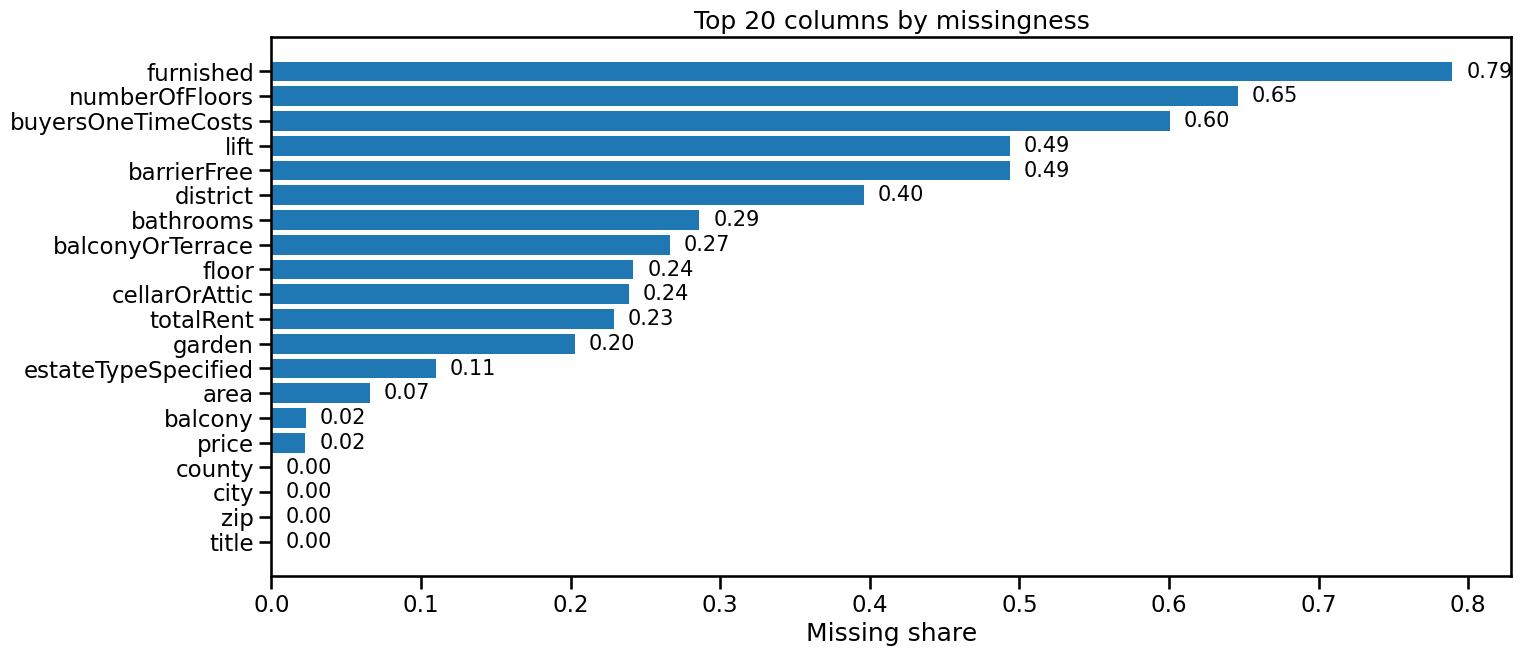

In [6]:
# Missingness overview (top 20)
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_rate").head(20))

# Plot missingness rates (top 20)
top = missing.head(20)[::-1]  # reverse for nicer plotting
plt.figure(figsize=(16, 7))
bars = plt.barh(top.index, top.values)
plt.xlabel("Missing share")
plt.title("Top 20 columns by missingness")
# Add value labels on bars
plt.bar_label(bars, fmt='%.2f', padding=10,fontsize=15)



plt.show()

### 2.4.3 Is missingness random or systematic?

A practical classroom-friendly approach:
- Create a missing indicator (e.g., `furnished_isna`)
- Compare missing rates across **platforms**

If missing rates differ strongly by platform, missingness is **systematic** (not random).

**Important note on rent definitions:**
- `price` is **cold rent (Kaltmiete)** and is the most complete/consistent rent variable across platforms.
- `totalRent` is **warm rent (Warmmiete)** but is often missing or inconsistently populated.

➡️ **Decision:** Use **cold rent (`price`)** as the primary rent measure in all analyses. We only use `totalRent` (if at all) to *diagnose* data quality/missingness.


,furnished,lift,barrierFree,floor,bathrooms,totalRent,area,price
main_platform,,,,,,,,
ebay,0.752119,0.872135,0.897207,0.318411,0.224895,0.385352,0.144737,0.055447
immoscout,0.876284,0.085066,0.000793,0.179323,0.087282,0.071269,0.019438,0.000378
immowelt,0.801889,0.709669,0.881526,0.262237,0.997073,0.278532,0.012222,0.008359
multiple,0.668175,0.207383,0.167276,0.159404,0.218014,0.125496,0.010910,0.000186


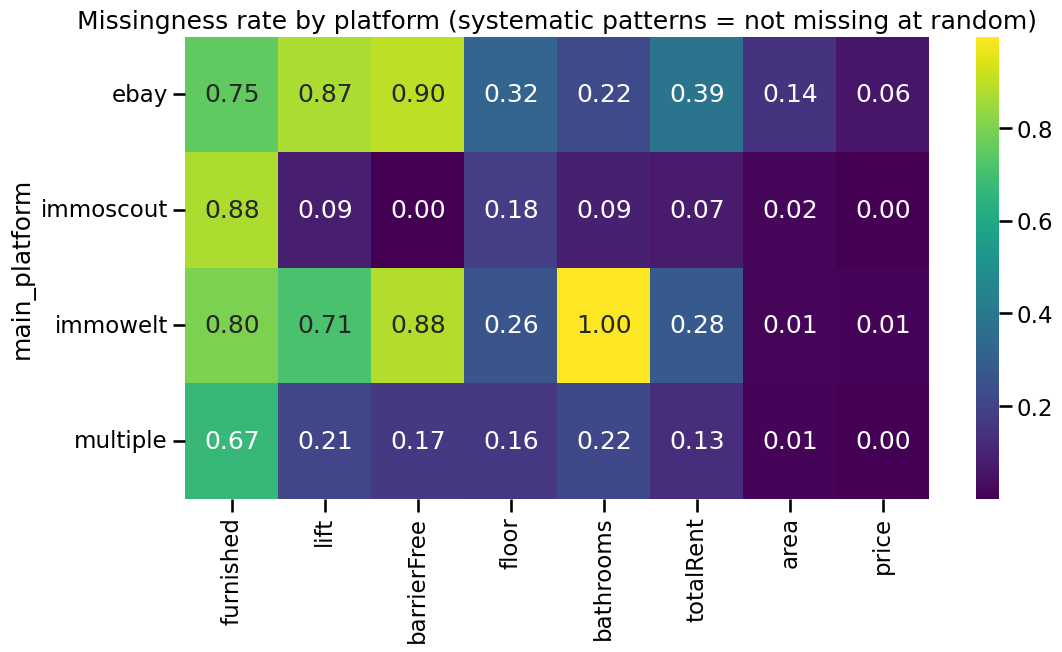

In [7]:
# Compare missingness by platform for selected columns
cols_to_check = ["furnished", "lift", "barrierFree", "floor", "bathrooms", "totalRent", "area", "price"]  # totalRent = warm rent (diagnostic only)

miss_by_platform = (
    df.groupby("main_platform")[cols_to_check]
      .apply(lambda g: g.isna().mean())
      .sort_index()
)

display(miss_by_platform)

plt.figure(figsize=(12, 6))
sns.heatmap(miss_by_platform, annot=True, fmt='.2f', cmap="viridis")
plt.title("Missingness rate by platform (systematic patterns = not missing at random)")
plt.ylabel("main_platform")
plt.show()

,furnished,lift,barrierFree,floor,bathrooms,totalRent,area,price
main_platform,,,,,,,,
ebay,0.752119,0.872135,0.897207,0.318411,0.224895,0.385352,0.144737,0.055447
immoscout,0.876284,0.085066,0.000793,0.179323,0.087282,0.071269,0.019438,0.000378
immowelt,0.801889,0.709669,0.881526,0.262237,0.997073,0.278532,0.012222,0.008359


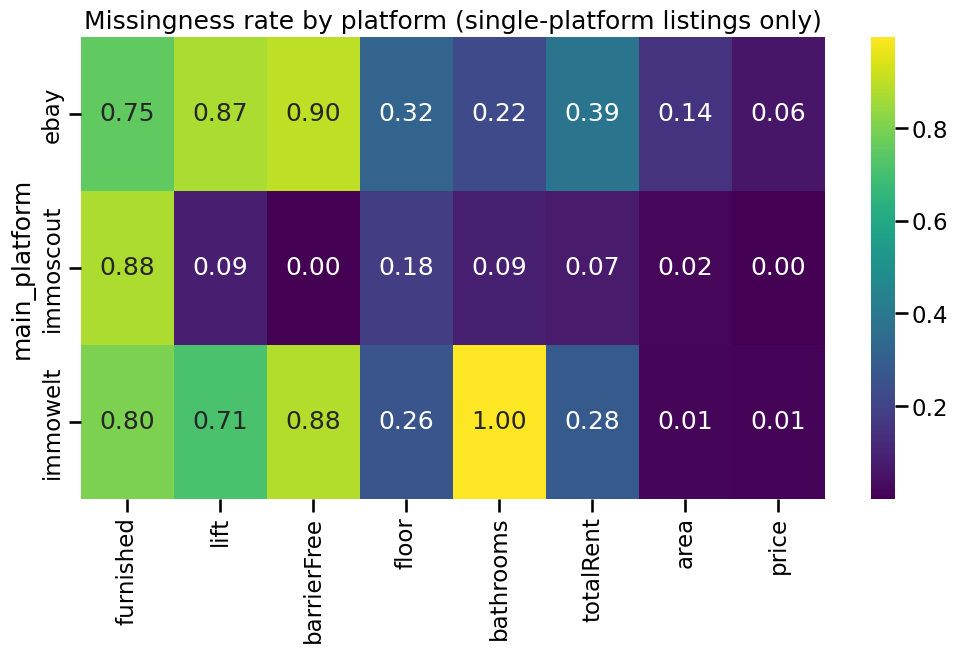

In [8]:
# Single-platform-only view (exclude cross-posted multi-platform listings)
_df_single = df[df["main_platform"] != "multiple"].copy()

cols_to_check = ["furnished", "lift", "barrierFree", "floor", "bathrooms", "totalRent", "area", "price"]
miss_by_platform_single = (
    _df_single.groupby("main_platform")[cols_to_check]
      .apply(lambda g: g.isna().mean())
      .sort_index()
)

display(miss_by_platform_single)

plt.figure(figsize=(12, 6))
sns.heatmap(miss_by_platform_single, annot=True, fmt='.2f', cmap="viridis")
plt.title("Missingness rate by platform (single-platform listings only)")
plt.ylabel("main_platform")
plt.show()


## 2.5 Duplicates and near-duplicates

Even if `_id` is unique, the same physical unit can be:
- cross-posted across platforms (syndication)
- re-posted with a new ID (renewed offer)
- listed with tiny text changes

We look for **near-duplicates** using an approximate key:
`(title, zip, price, area)`


In [9]:
key_cols = ["title", "zip", "price", "area"]
df["dup_key"] = df[key_cols].astype(str).agg("|".join, axis=1)

near_dup_share = df["dup_key"].duplicated().mean()
print("Approximate near-duplicate share (title+zip+price+area):", round(near_dup_share, 4))

# 1. Identify all duplicate rows
dups = df[df["dup_key"].duplicated(keep=False)].copy()
# 2. Get the unique keys that have duplicates and pick the first 3
sample_keys = dups["dup_key"].unique()[:3]
# 3. Filter to get ONLY the rows belonging to these 3 keys
example_dups = dups[dups["dup_key"].isin(sample_keys)]
# 4. Sort by 'dup_key' so the pairs/groups appear together in the list
example_dups = example_dups.sort_values(by="dup_key")

print(f"\nShowing 3 Example Groups of Duplicates")
display(example_dups[key_cols + ["platforms", "firstSeen", "lastSeen"]])

Approximate near-duplicate share (title+zip+price+area): 0.0122

Showing 3 Example Groups of Duplicates


,title,zip,price,area,platforms,firstSeen,lastSeen
243,2 Zimmer Wohnung in Seeon,83370,540.0,55.0,['ebay'],2023-01-01 17:34:05.785,2023-01-13 20:05:18.638
9385,2 Zimmer Wohnung in Seeon,83370,540.0,55.0,['ebay'],2023-01-13 20:36:02.089,2023-01-30 20:06:07.631
233,2 Zimmerwohnung nähe Bahnhof Eggmühl zu vermieten,84069,NaN,64.0,['ebay'],2023-01-01 17:18:04.413,2023-02-27 20:06:10.511
42016,2 Zimmerwohnung nähe Bahnhof Eggmühl zu vermieten,84069,NaN,64.0,['ebay'],2023-02-28 19:13:03.657,2023-03-12 20:22:36.626
138,CHARMING AND QUITE FURNISHED ROOM IN A VIVID F...,90763,350.0,NaN,['immoscout'],2023-01-01 14:00:04.149,2023-01-09 20:11:56.473
35409,CHARMING AND QUITE FURNISHED ROOM IN A VIVID F...,90763,350.0,NaN,['immoscout'],2023-02-19 05:28:02.609,2023-02-20 20:12:29.357


## 2.6 Sanity checks and interpretability: distributions & outliers

Two classic pitfalls in listing data:
- `price` and `area` can contain **extreme outliers** (e.g., parsing errors, wrong units, sale prices)
- Correlations and averages can become meaningless if outliers dominate

We therefore:
1. Visualize distributions (often on a **log scale**)
2. Define **analysis-ready** subsets using robust quantile trimming
   - This is not “deleting data for convenience”
   - It is a transparent way to focus on the plausible range for *rental* listings

We keep the **raw columns untouched** and create cleaned versions.

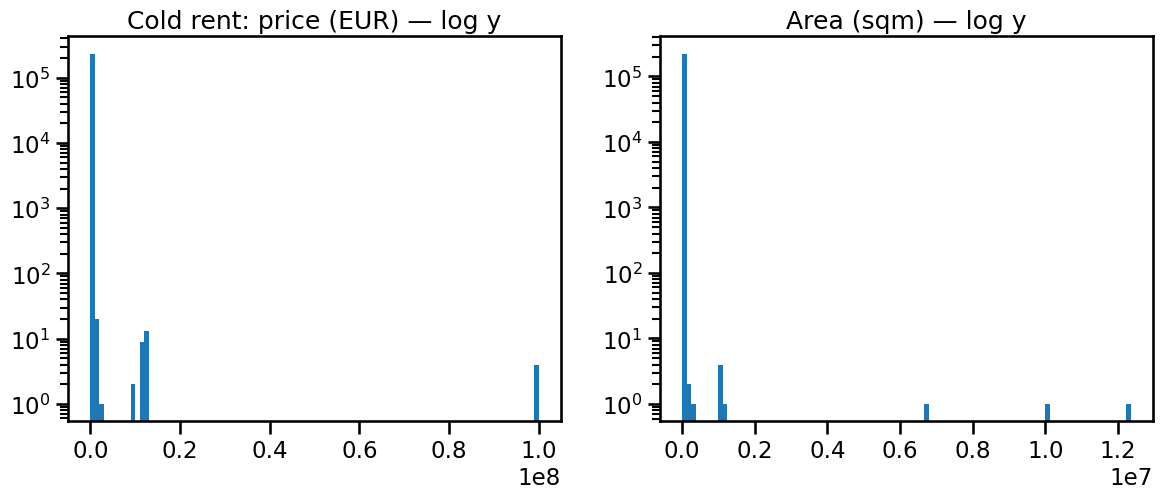

Trim retention:
  price_trim     : 226,094/235,930 (95.8%)
  area_trim      : 216,172/235,930 (91.6%)
  both (price+area): 209,049/235,930 (88.6%)


,price,price_trim,area,area_trim
count,2.305660e+05,226094.000000,2.204440e+05,216172.000000
mean,4.441315e+03,1030.437290,2.454865e+02,75.684839
std,4.337374e+05,552.237794,3.707063e+04,33.836200
min,5.000000e-01,250.000000,1.000000e-01,18.000000
25%,6.300000e+02,640.000000,5.200000e+01,52.000000
50%,9.000000e+02,900.000000,7.000000e+01,70.000000
75%,1.300000e+03,1295.000000,9.400000e+01,93.000000
max,1.000000e+08,3600.000000,1.234568e+07,203.000000


In [10]:
# Distributions of key variables (log scale helps)
# We focus on *cold rent* (price) for analysis; warm rent (totalRent) is treated as optional/diagnostic.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"].dropna(), bins=100, log=True)
axes[0].set_title("Cold rent: price (EUR) — log y")

axes[1].hist(df["area"].dropna(), bins=100, log=True)
axes[1].set_title("Area (sqm) — log y")

plt.show()

# Quantile-based trimming for analysis columns (very common in EDA)
def quantile_trim(s, low=0.01, high=0.99):
    lo, hi = s.quantile(low), s.quantile(high)
    return s.where((s >= lo) & (s <= hi))

# Winsorization (cap extremes instead of dropping them) — useful as a sensitivity check
def quantile_winsorize(s, low=0.01, high=0.99):
    lo, hi = s.quantile(low), s.quantile(high)
    return s.clip(lower=lo, upper=hi)

df["price_trim"] = quantile_trim(df["price"], 0.01, 0.99)
df["area_trim"] = quantile_trim(df["area"], 0.01, 0.99)
df["bathrooms_trim"] = quantile_trim(df["bathrooms"], 0.01, 0.99)
df["floor_trim"] = quantile_trim(df["floor"], 0.01, 0.99)

# How much data do we retain after trimming?
N = len(df)
print("Trim retention:")
print("  price_trim     : {:,}/{:,} ({:.1%})".format(df["price_trim"].notna().sum(), N, df["price_trim"].notna().mean()))
print("  area_trim      : {:,}/{:,} ({:.1%})".format(df["area_trim"].notna().sum(), N, df["area_trim"].notna().mean()))
print("  both (price+area): {:,}/{:,} ({:.1%})".format(df[["price_trim","area_trim"]].dropna().shape[0], N, df[["price_trim","area_trim"]].dropna().shape[0]/N))

# Winsorized variants (same quantiles, but capped)
df["price_win"] = quantile_winsorize(df["price"], 0.01, 0.99)
df["area_win"] = quantile_winsorize(df["area"], 0.01, 0.99)
df["bathrooms_win"] = quantile_winsorize(df["bathrooms"], 0.01, 0.99)
df["floor_win"] = quantile_winsorize(df["floor"], 0.01, 0.99)

df[["price", "price_trim", "area", "area_trim"]].describe()


In [11]:
# Sensitivity check: trimmed vs winsorized (caps extremes instead of dropping)

# Area vs price correlation
_tmp_trim = df[["area_trim", "price_trim"]].dropna()
_tmp_win  = df[["area_win",  "price_win"]].dropna()

print("Area vs price correlation")
print("  Trimmed   Pearson:", round(_tmp_trim["area_trim"].corr(_tmp_trim["price_trim"], method="pearson"), 4),
      "Spearman:", round(_tmp_trim["area_trim"].corr(_tmp_trim["price_trim"], method="spearman"), 4))
print("  Winsorized Pearson:", round(_tmp_win["area_win"].corr(_tmp_win["price_win"], method="pearson"), 4),
      "Spearman:", round(_tmp_win["area_win"].corr(_tmp_win["price_win"], method="spearman"), 4))

# Duration vs price correlation (using trimmed vs winsorized price)
_tmp_dur_trim = df[["daysActive_clean", "price_trim"]].dropna()
_tmp_dur_win  = df[["daysActive_clean", "price_win"]].dropna()

print("\nDuration vs price correlation")
print("  Trimmed   Pearson:", round(_tmp_dur_trim["daysActive_clean"].corr(_tmp_dur_trim["price_trim"], method="pearson"), 4),
      "Spearman:", round(_tmp_dur_trim["daysActive_clean"].corr(_tmp_dur_trim["price_trim"], method="spearman"), 4))
print("  Winsorized Pearson:", round(_tmp_dur_win["daysActive_clean"].corr(_tmp_dur_win["price_win"], method="pearson"), 4),
      "Spearman:", round(_tmp_dur_win["daysActive_clean"].corr(_tmp_dur_win["price_win"], method="spearman"), 4))


Area vs price correlation


  Trimmed   Pearson: 0.5769 Spearman: 0.5929
  Winsorized Pearson: 0.6028 Spearman: 0.6073

Duration vs price correlation
  Trimmed   Pearson: -0.0098 Spearman: 0.105
  Winsorized Pearson: -0.0065 Spearman: 0.1093


# 3) Exploratory Analysis and Visualization

We start with:
- univariate distributions (duration, price, area)
- platform comparisons
- bivariate relationships (correlation + visuals)


- Skewed continuous variables → log scale / trimmed subset / boxplots
- Dense scatter → transparency (`alpha`) or hexbin
- Correlation matrices → heatmaps

## 3.1 Listing duration (`daysActive_clean`) overall and by platform

Because most observations come from a single platform, we use `main_platform`.
For multi-platform listings, we keep them in a separate category (`multiple`).

We compare platform distributions using:
- summary table (mean/median)
- boxplot (robust to outliers)

,count,mean,median,p25,p75
main_platform,,,,,
multiple,32264,255.871109,113.320326,23.985138,491.291335
immoscout,79432,66.962982,13.992763,5.977801,35.381669
immowelt,33138,66.008067,13.353219,5.393217,43.385255
ebay,91096,46.191274,11.077035,3.018106,33.386670


C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\1304922160.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="main_platform", y="daysActive_clean", palette=["#E63946", "#1D3557", "#06A77D", "#F77F00"])


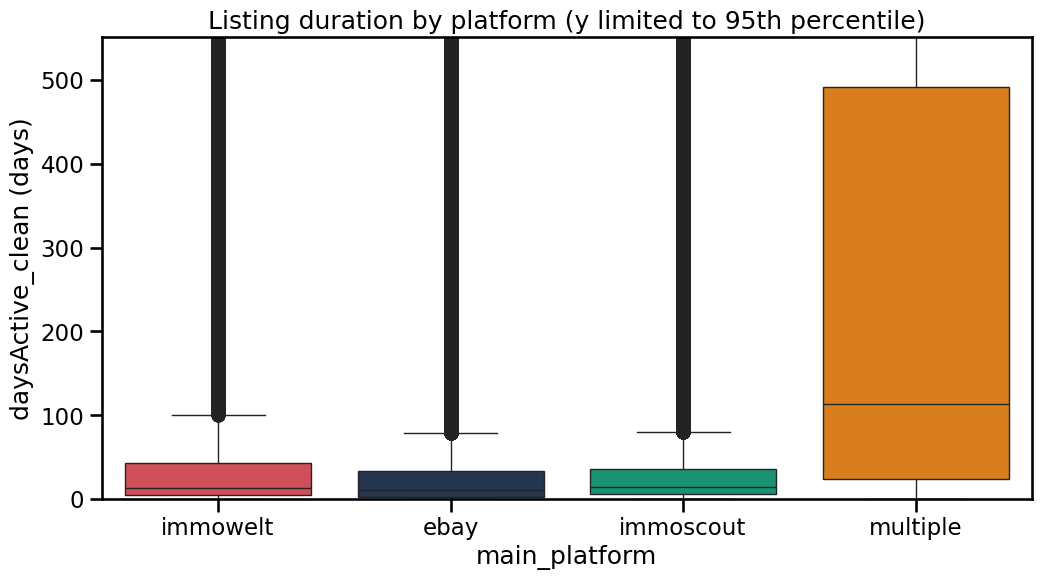

In [12]:
# Summary stats by platform
# Using explicit quartiles for clarity
dur_stats = (df.groupby("main_platform")["daysActive_clean"]
               .agg(count="count",
                    mean="mean",
                    median="median",
                    p25=lambda x: x.quantile(0.25),
                    p75=lambda x: x.quantile(0.75))
            ).sort_values("median", ascending=False)

display(dur_stats)

# Boxplot (trim y-axis to improve readability)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="main_platform", y="daysActive_clean", palette=["#E63946", "#1D3557", "#06A77D", "#F77F00"])
plt.ylim(0, df["daysActive_clean"].quantile(0.95))
plt.title("Listing duration by platform (y limited to 95th percentile)")
plt.ylabel("daysActive_clean (days)")
plt.xlabel("main_platform")
plt.show()

,count,mean,median,p25,p75
main_platform,,,,,
immoscout,79432,66.962982,13.992763,5.977801,35.381669
immowelt,33138,66.008067,13.353219,5.393217,43.385255
ebay,91096,46.191274,11.077035,3.018106,33.386670


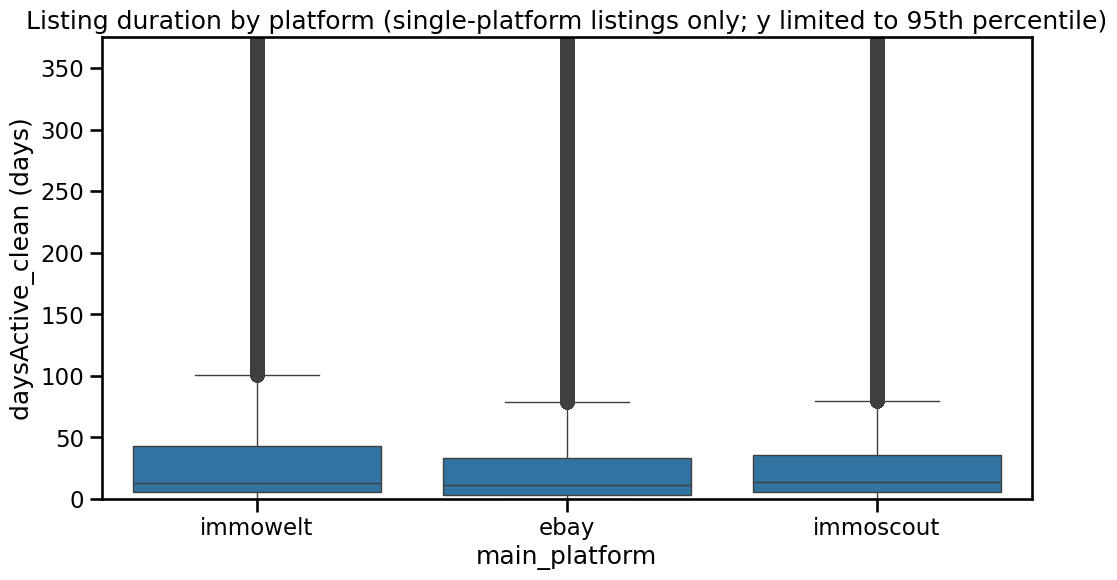

In [13]:
# Single-platform-only: duration summary
_df_single = df[df["main_platform"] != "multiple"].copy()

_dur_stats_single = (_df_single.groupby("main_platform")["daysActive_clean"]
                      .agg(count="count",
                           mean="mean",
                           median="median",
                           p25=lambda x: x.quantile(0.25),
                           p75=lambda x: x.quantile(0.75))
                     ).sort_values("median", ascending=False)

display(_dur_stats_single)

plt.figure(figsize=(12, 6))
sns.boxplot(data=_df_single, x="main_platform", y="daysActive_clean")
plt.ylim(0, _df_single["daysActive_clean"].quantile(0.95))
plt.title("Listing duration by platform (single-platform listings only; y limited to 95th percentile)")
plt.ylabel("daysActive_clean (days)")
plt.xlabel("main_platform")
plt.show()


### 3.1.1 Distribution of listing duration

We show:
- histogram (log y optional)  
- percentiles to interpret typical durations (e.g., median vs tail)

count    235930.000000
mean         84.642244
std         173.855913
min           0.000000
50%          14.088943
75%          53.222093
90%         326.180719
95%         551.161395
99%         774.527416
max         970.483963
Name: daysActive_clean, dtype: float64


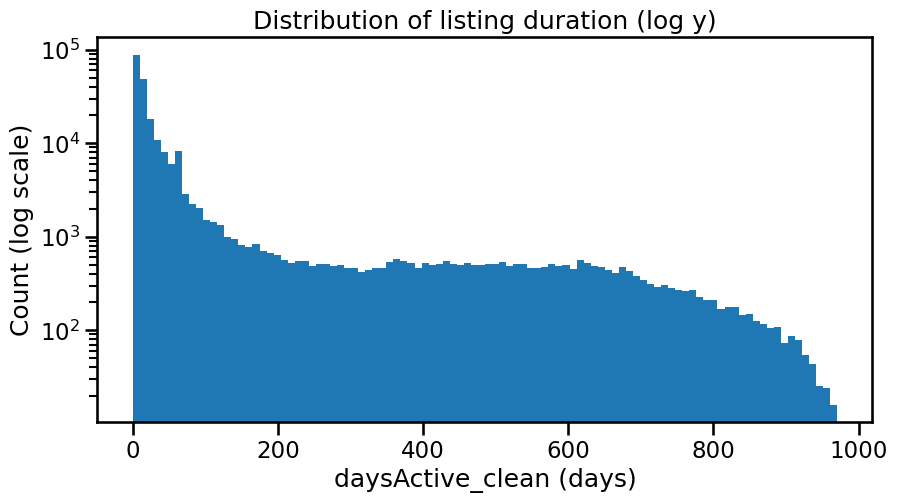

In [14]:
print(df["daysActive_clean"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(10, 5))
plt.hist(df["daysActive_clean"].dropna(), bins=100, log=True)
plt.title("Distribution of listing duration (log y)")
plt.xlabel("daysActive_clean (days)")
plt.ylabel("Count (log scale)")
plt.show()

## 3.2 Correlation between listing duration and price

We analyze `daysActive_clean` vs `price_trim`:
- use trimming to reduce distortion from extreme price errors
- compute **Pearson** (linear) and **Spearman** (rank-based, robust to skew/outliers)
- visualize with scatter + trend line

**Interpretation caution:**  
If a variable has strong skew or many outliers, a “simple average” or a single correlation number can be misleading.
That’s why we show **a plot** and **two correlation metrics**.

Correlation daysActive vs price (trimmed):
  Pearson : -0.0098
  Spearman: 0.105


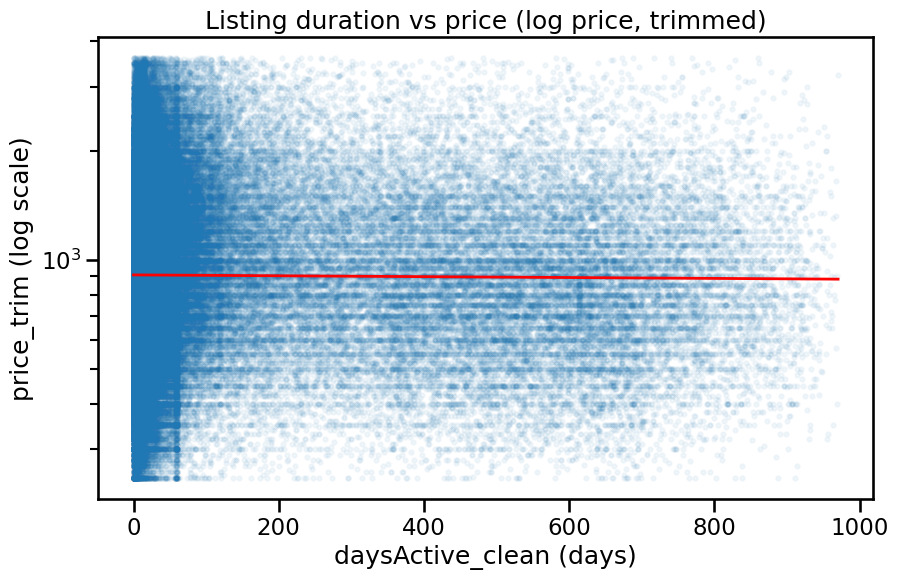

In [15]:
# Prepare analysis subset: need both values
sub = df[["daysActive_clean", "price_trim", "main_platform"]].dropna()

pearson = sub["daysActive_clean"].corr(sub["price_trim"], method="pearson")
spearman = sub["daysActive_clean"].corr(sub["price_trim"], method="spearman")

print("Correlation daysActive vs price (trimmed):")
print("  Pearson :", round(pearson, 4))
print("  Spearman:", round(spearman, 4))

# Scatter plot (dense → use alpha)
plt.figure(figsize=(10, 6))
plt.scatter(sub["daysActive_clean"], sub["price_trim"], alpha=0.05, s=10)
# Fit regression line manually for log scale using numpy
x = sub["daysActive_clean"].values
y_log = np.log10(sub["price_trim"].values)
# Remove any inf or nan values
mask = np.isfinite(x) & np.isfinite(y_log)
x_clean = x[mask]
y_log_clean = y_log[mask]
# Fit polynomial of degree 1 (linear regression)
coeffs = np.polyfit(x_clean, y_log_clean, 1)
x_line = np.linspace(sub["daysActive_clean"].min(), sub["daysActive_clean"].max(), 100)
y_line = 10**(coeffs[0] * x_line + coeffs[1])
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Regression line')
plt.yscale("log")
plt.title("Listing duration vs price (log price, trimmed)")
plt.xlabel("daysActive_clean (days)")
plt.ylabel("price_trim (log scale)")
plt.show()

## 3.3 Correlation between area and price (visual + correlation)

We compute correlation between `area_trim` and `price_trim` and show it graphically.

**Why trimming helps here:**  
A single area of “12,345,678 sqm” (parsing error) can destroy correlation and scaling.

Correlation area vs price (trimmed):
  Pearson : 0.5769
  Spearman: 0.5929


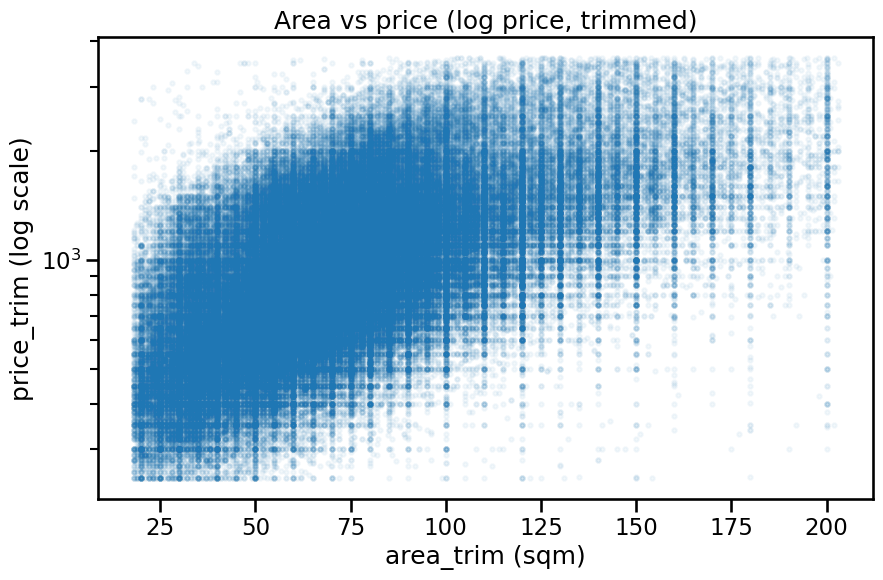

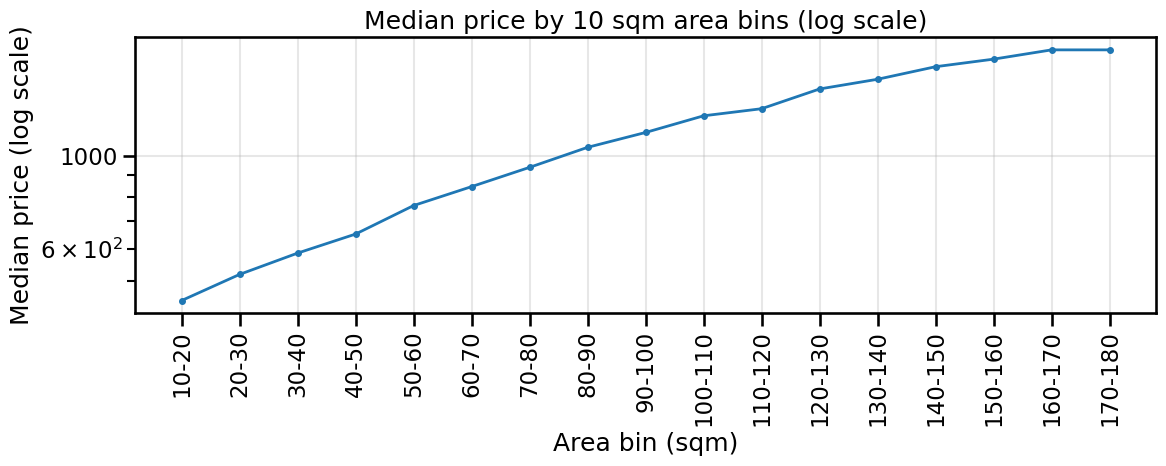

In [16]:
sub2 = df[["area_trim", "price_trim"]].dropna()

pearson_ap = sub2["area_trim"].corr(sub2["price_trim"], method="pearson")
spearman_ap = sub2["area_trim"].corr(sub2["price_trim"], method="spearman")

print("Correlation area vs price (trimmed):")
print("  Pearson :", round(pearson_ap, 4))
print("  Spearman:", round(spearman_ap, 4))

plt.figure(figsize=(10, 6))
plt.scatter(sub2["area_trim"], sub2["price_trim"], alpha=0.05, s=10)
plt.yscale("log")
plt.title("Area vs price (log price, trimmed)")
plt.xlabel("area_trim (sqm)")
plt.ylabel("price_trim (log scale)")
plt.show()

# A binned view: median price by area bin (great for presentations)
bins = pd.cut(sub2["area_trim"], bins=np.arange(0, sub2["area_trim"].quantile(0.99)+10, 10))
median_by_bin = sub2.groupby(bins, observed=True)["price_trim"].median()

# Format bin labels to show as "10-20", "20-30", etc.
def format_bin_label(interval):
    """Convert interval like (10.0, 20.0] to '10-20'"""
    if pd.notna(interval):
        left = int(interval.left)
        right = int(interval.right)
        return f"{left}-{right}"
    return str(interval)

bin_labels = [format_bin_label(interval) for interval in median_by_bin.index]

plt.figure(figsize=(12, 5))
plt.plot(range(len(median_by_bin)), median_by_bin.values, marker='o', linewidth=2, markersize=4)
plt.yscale("log")

# Format y-axis to show numbers without decimals (as integers)
import matplotlib.ticker as ticker
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y)}'))

# Set x-axis labels to the formatted bin labels
plt.xticks(range(len(bin_labels)), bin_labels, rotation=90)
plt.title("Median price by 10 sqm area bins (log scale)")
plt.xlabel("Area bin (sqm)")
plt.ylabel("Median price (log scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Correlation bar chart: **cold rent** (`price`) vs property features

Requested features:
- `Area` (`area`)
- `balcony`
- `barrierFree`
- `bathrooms`
- `cellarOrAttic`
- `estateType`
- `floor`
- `lift`
- `newlyConstructed`
- `furnished`

We compute correlations using trimmed numeric columns:
- `price_trim`, `area_trim`, etc.

### Handling booleans and missingness
We convert boolean-like columns to numeric **only where present**, keeping missing values as `NaN`.
This avoids the assumption “missing = False”.


### 3.4.1 Alternative visualization: rank correlations with **cold rent**
For storytelling it often helps to **rank** effects.
Below we plot Spearman correlations of key numeric variables with `price_trim` (cold rent).

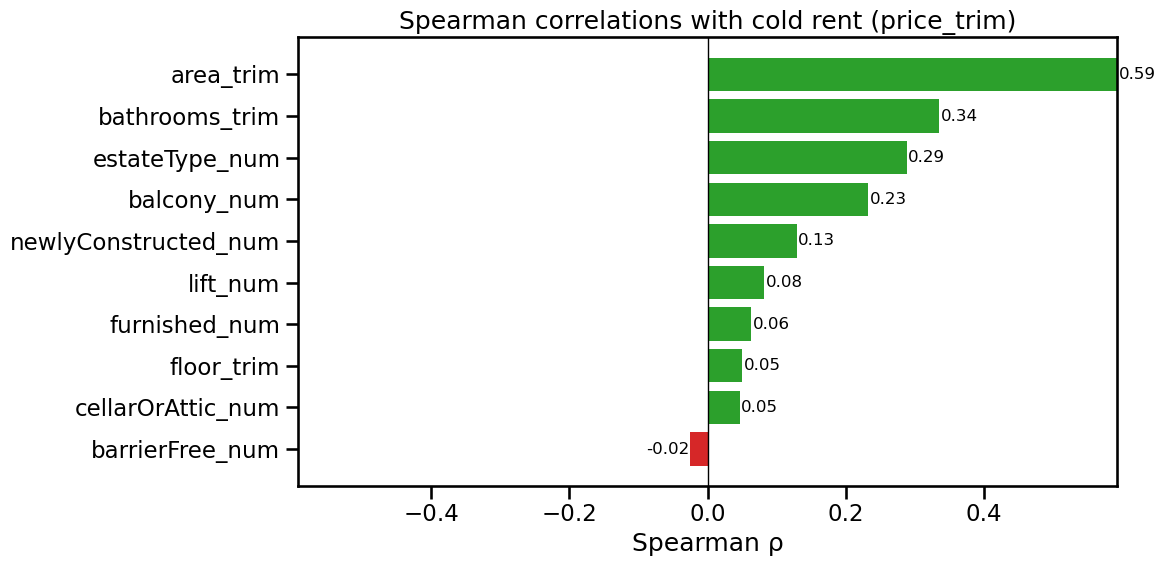

area_trim               0.592910
bathrooms_trim          0.335086
estateType_num          0.287994
balcony_num             0.232029
newlyConstructed_num    0.128876
lift_num                0.082123
furnished_num           0.063119
floor_trim              0.049841
cellarOrAttic_num       0.046768
barrierFree_num        -0.024796
Name: price_trim, dtype: float64

In [17]:
import matplotlib.pyplot as plt

# 1. Data Preparation (Same as your code)
# Convert boolean columns to numeric (True->1, False->0, NaN stays NaN)
bool_cols = ["balcony", "barrierFree", "cellarOrAttic", "lift", "newlyConstructed", "furnished"]

for c in bool_cols:
    if c in df.columns: # Safety check
        df[c + "_num"] = df[c].map({True: 1, False: 0})

# estateType: only two categories (apartment/house). Encode house=1, apartment=0
if "estateType" in df.columns:
    df["estateType_num"] = df["estateType"].map({"apartment": 0, "house": 1})

corr_cols = [
    "price_trim", "area_trim",
    "balcony_num", "barrierFree_num", "bathrooms_trim",
    "cellarOrAttic_num", "estateType_num", "floor_trim",
    "lift_num", "newlyConstructed_num", "furnished_num"
]

# Check which columns actually exist in df before correlating
existing_cols = [c for c in corr_cols if c in df.columns]
corr_tmp = df[existing_cols].copy()

# Calculate Spearman Correlation
corrs = corr_tmp.corr(method="spearman")["price_trim"].drop("price_trim").sort_values()

# Color code: negative vs positive correlations
colors = ["tab:red" if v < 0 else "tab:green" for v in corrs.values]

# 2. Plotting with Labels
fig, ax = plt.subplots(figsize=(12, 6))

# Create the Horizontal Bars
bars = ax.barh(corrs.index, corrs.values, color=colors)

# --- ADD LABELS HERE ---
# fmt='%.2f' rounds to 2 decimal places
# padding=3 adds a small space between bar and text
ax.bar_label(bars, fmt='%.2f', padding=1,fontsize=12)

# Adjust X-axis limits to make room for labels on both sides
limit = max(abs(corrs.values.min()), abs(corrs.values.max())) * 1
ax.set_xlim(-limit, limit)

# Styling
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Spearman correlations with cold rent (price_trim)")
ax.set_xlabel("Spearman ρ")

plt.tight_layout()
plt.show()

display(corrs.sort_values(ascending=False))

## 3.5 Additional EDA: price per sqm and regional patterns

A common real-estate metric is **rent per sqm**:
\[
\text{rent\_per\_sqm} = \frac{\text{price}}{\text{area}}
\]

It helps compare listings of different sizes.

We will:
- compute `rent_per_sqm` (trimmed inputs)
- show distribution
- compare by platform and by county (top 15 counties by number of listings)

> Again: we avoid filling missing area/price with zeros. We simply compute this where both are present and plausible.

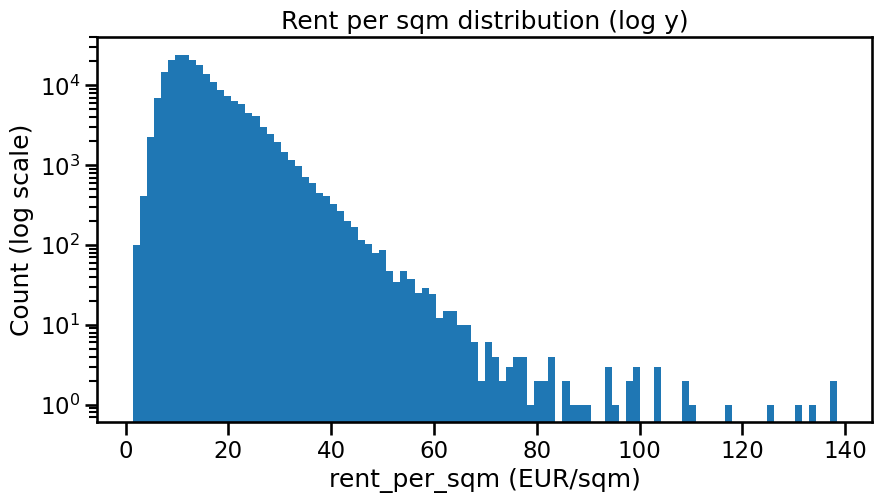

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\3191982155.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="main_platform", y="rent_per_sqm", palette=["#E63946", "#1D3557", "#06A77D", "#F77F00"])


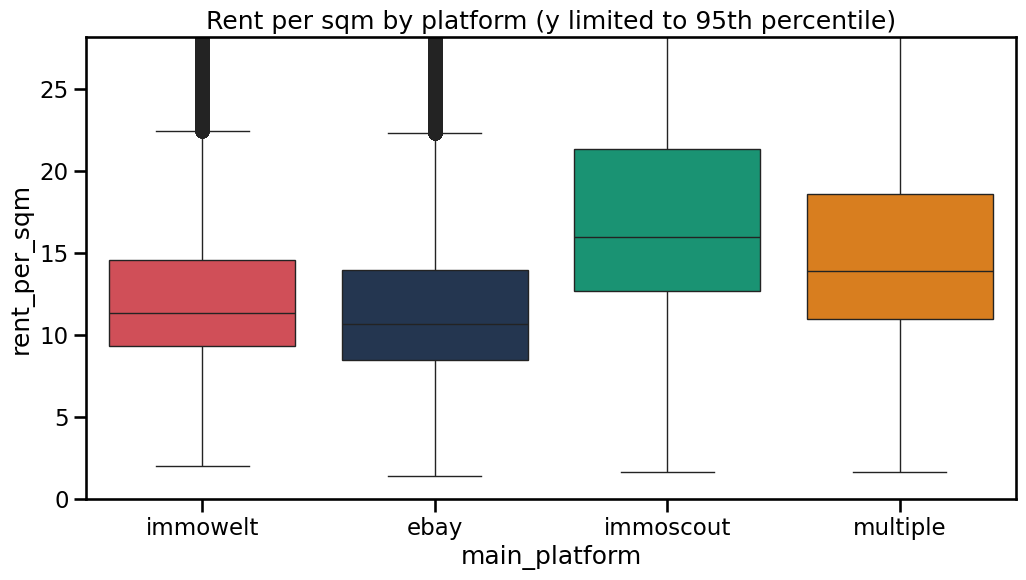

In [18]:
df["rent_per_sqm"] = df["price_trim"] / df["area_trim"]

plt.figure(figsize=(10, 5))
plt.hist(df["rent_per_sqm"].dropna(), bins=100, log=True)
plt.title("Rent per sqm distribution (log y)")
plt.xlabel("rent_per_sqm (EUR/sqm)")
plt.ylabel("Count (log scale)")
plt.show()

# By platform (boxplot, limited y)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="main_platform", y="rent_per_sqm", palette=["#E63946", "#1D3557", "#06A77D", "#F77F00"])
plt.ylim(0, df["rent_per_sqm"].quantile(0.95))
plt.title("Rent per sqm by platform (y limited to 95th percentile)")
plt.ylabel("rent_per_sqm")
plt.show()

# Regional comparison: top 15 counties by count
county_stats = (df.dropna(subset=["rent_per_sqm", "county"])
                  .groupby("county")["rent_per_sqm"]
                  .agg(count="count", median="median")
                  .sort_values("count", ascending=False)
               )

### 3.5.1 Top 10 cities by rent per sqm
Ching's notebook added a useful city-level view. We keep the idea, but compute it from the `city` field extracted from the `location` dictionary. 

**Notes for interpretation:**
- City names come from platform text fields → possible spelling variants ("München" vs "Munich").
- To reduce noise, we only rank cities with **at least 100** listings with non-missing `rent_per_sqm`.


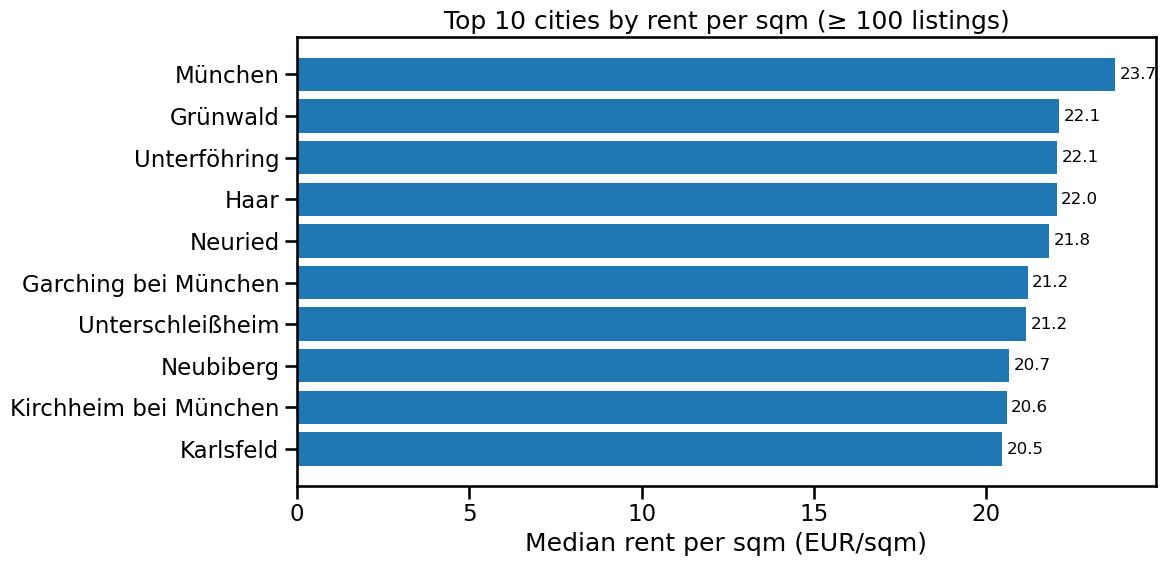

,count,median,mean
city,,,
München,34789,23.731343,24.742042
Grünwald,114,22.113047,22.893498
Unterföhring,190,22.050336,22.019568
Haar,478,22.040656,21.945159
Neuried,121,21.818182,21.735011
Garching bei München,261,21.200000,22.261836
Unterschleißheim,601,21.153846,21.469498
Neubiberg,232,20.662286,21.557524
Kirchheim bei München,322,20.597530,20.750567


In [19]:
# Top cities by rent per sqm (only sufficiently frequent cities)
city_stats = (df.dropna(subset=["city", "rent_per_sqm"])
                .groupby("city")["rent_per_sqm"]
                .agg(count="count", median="median", mean="mean")
             )

city_stats_100 = city_stats[city_stats["count"] >= 100]

# Two useful rankings: median (robust) and mean (sensitive to outliers)
top10_median = city_stats_100.sort_values("median", ascending=False).head(10).sort_values("median")
top10_mean   = city_stats_100.sort_values("mean",   ascending=False).head(10).sort_values("mean")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_median.index, top10_median["median"])
ax.set_title("Top 10 cities by rent per sqm (≥ 100 listings)")
ax.set_xlabel("Median rent per sqm (EUR/sqm)")

# Value labels
ax.bar_label(bars, fmt="%.1f", padding=3,fontsize=12)
plt.tight_layout()
plt.show()

display(top10_median.sort_values("median", ascending=False))


### 3.5.2 Size distribution by top 10 cities (size by listing count)
A boxplot helps compare the **typical size** and variability across cities, while being robust to a few extreme outliers.


C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\4263151381.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


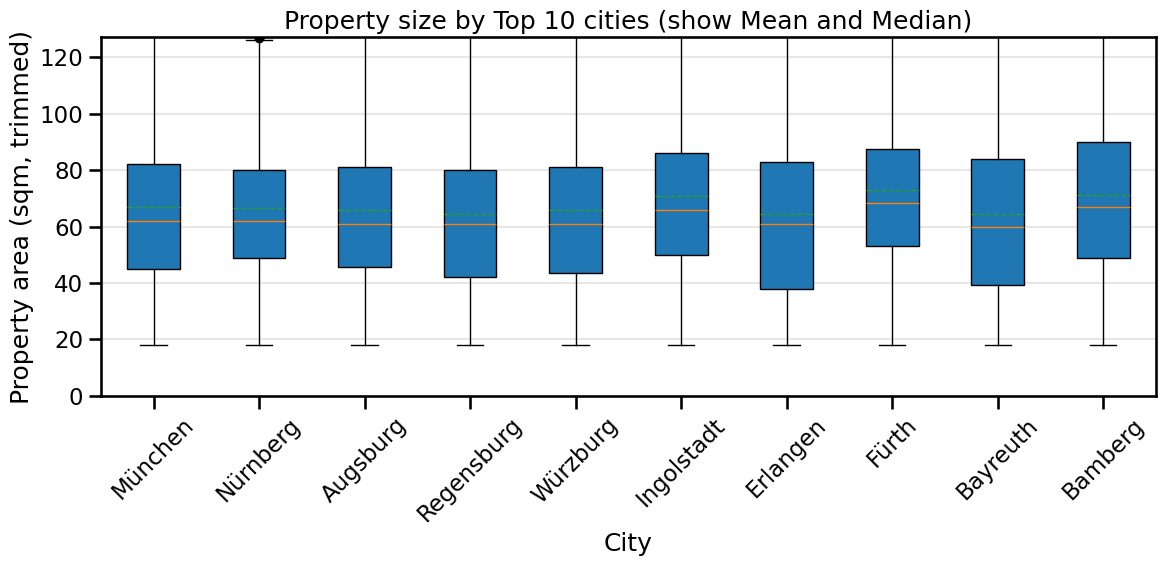

,count,mean,50%,std
city,,,,
München,36234.0,66.967707,62.00,31.338740
Nürnberg,14071.0,66.597432,62.00,28.109623
Augsburg,6668.0,65.895411,61.00,29.280731
Regensburg,4925.0,64.490930,61.00,30.688872
Würzburg,3910.0,65.736460,60.92,31.166497
Ingolstadt,3167.0,70.939937,66.00,31.094534
Erlangen,2715.0,64.600733,61.00,32.340380
Fürth,2314.0,72.797269,68.50,30.069679
Bayreuth,1932.0,64.601128,60.00,32.951361


In [20]:
top_cities_by_count = df["city"].value_counts().head(10).index
size_df = df[df["city"].isin(top_cities_by_count)].copy()

# Matplotlib boxplot gives a clean "show mean" option (key graphic from comparison notebook)
fig, ax = plt.subplots(figsize=(12, 6))

box_data = [
    size_df.loc[size_df["city"] == city, "area_trim"].dropna().values
    for city in top_cities_by_count
]

ax.boxplot(
    box_data,
    labels=top_cities_by_count,
    patch_artist=True,
    showmeans=True,
    meanline=True,
)

ax.set_ylabel("Property area (sqm, trimmed)")
ax.set_xlabel("City")
ax.set_title("Property size by Top 10 cities (show Mean and Median)")
ax.tick_params(axis='x', rotation=45)

# Keep outliers readable
if size_df["area_trim"].notna().any():
    ax.set_ylim(0, size_df["area_trim"].quantile(0.95))

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(size_df.groupby("city")["area_trim"].describe().loc[:, ["count", "mean", "50%", "std"]]
        .sort_values("count", ascending=False))


### 3.5.3 Top 10 cities by **cold rent**
To stay consistent (and avoid systematic missingness in warm rent), we rank cities by **median** cold rent (`price_trim`).


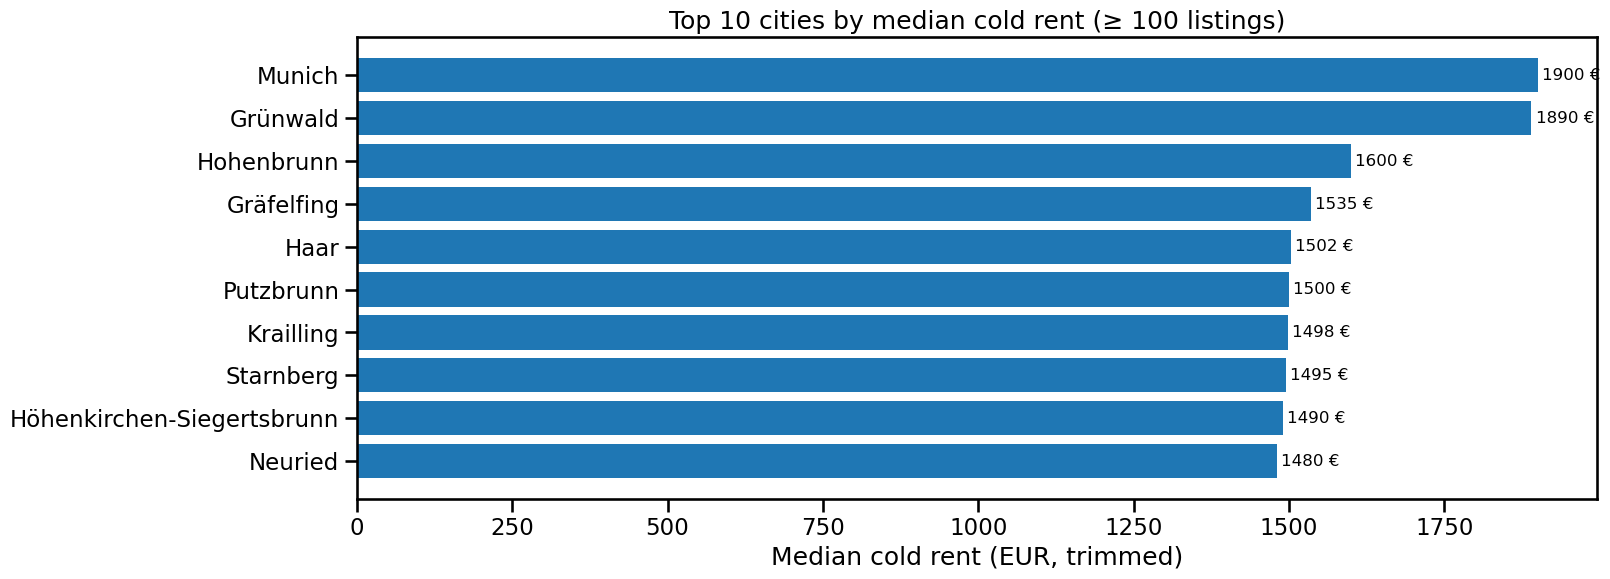

,count,median
city,,
Neuried,128,1480.21
Höhenkirchen-Siegertsbrunn,183,1490.00
Starnberg,497,1495.00
Krailling,144,1497.50
Putzbrunn,107,1500.00
Haar,500,1502.50
Gräfelfing,133,1535.00
Hohenbrunn,102,1600.00
Grünwald,128,1890.00


In [21]:
rent_city = (df.dropna(subset=["city", "price_trim"])
                 .groupby("city")["price_trim"]
                 .agg(count="count", median="median")
              )

rent_city_100 = rent_city[rent_city["count"] >= 100].sort_values("median", ascending=False)

top10_rent = rent_city_100.head(10).sort_values("median")

plt.figure(figsize=(16, 6))
# Assign to 'bars' to use for labeling later
bars = plt.barh(top10_rent.index, top10_rent["median"], color='#4c72b0')

# --- ADD LABELS CODE ---
# fmt='%.0f €' : Shows number as Integer + Euro sign (e.g., "1200 €")
# padding=3    : Adds space between the bar end and text
plt.bar_label(bars, fmt='%.0f €', padding=3, fontsize=12)

plt.barh(top10_rent.index, top10_rent["median"])
plt.title("Top 10 cities by median cold rent (≥ 100 listings)")
plt.xlabel("Median cold rent (EUR, trimmed)")
plt.show()

display(top10_rent)


## 3.6 Additional EDA: missingness and feature availability by platform

We already saw strong platform-specific missingness.  
Here is a “presentation-friendly” chart focusing on a few important features.

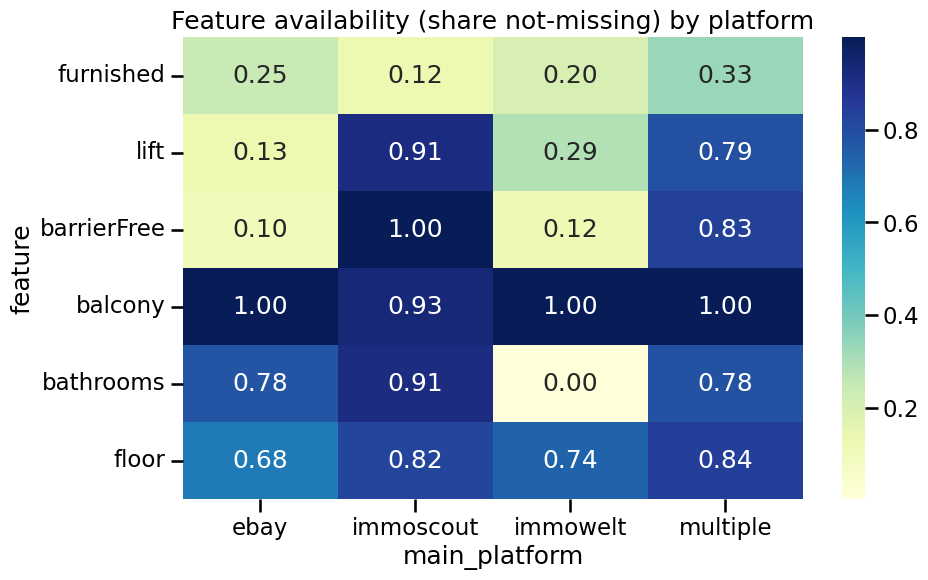

In [22]:
feature_cols = ["furnished", "lift", "barrierFree", "balcony", "bathrooms", "floor"]
miss_plot = (df.groupby("main_platform")[feature_cols]
               .apply(lambda g: g.notna().mean())
               .T
            )

plt.figure(figsize=(10, 6))
sns.heatmap(miss_plot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Feature availability (share not-missing) by platform")
plt.xlabel("main_platform")
plt.ylabel("feature")
plt.show()

## 3.7 Deep dive: time trends and market speed

### 3.7.1 Monthly rent trends across 2023
We use `firstSeen_dt` to assign each listing to the month it **first appeared** on the platforms.

To stay consistent across platforms (and avoid systematic missingness), we track **cold rent** using `price_trim`.

The plot below combines *rent level* and *listing volume* in one view using a dual axis (line + bars).

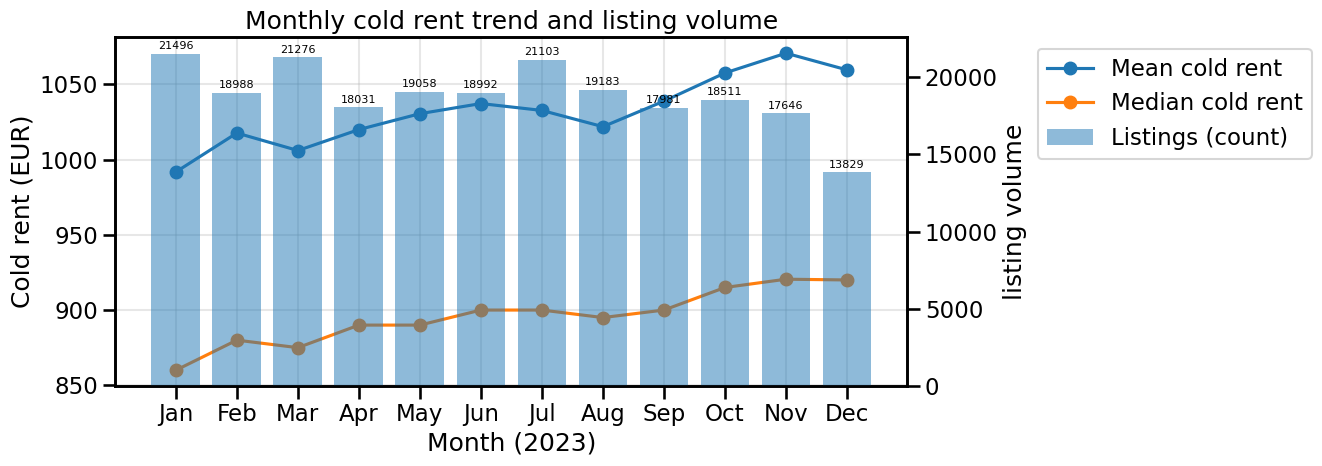

,month,mean_cold_rent,median_cold_rent,count,month_name
0,1,991.767704,860.0,21496,Jan
1,2,1017.667135,880.0,18988,Feb
2,3,1006.032250,875.0,21276,Mar
3,4,1019.948146,890.0,18031,Apr
4,5,1030.517089,890.0,19058,May
5,6,1037.248923,900.0,18992,Jun
6,7,1032.672708,900.0,21103,Jul
7,8,1021.870620,895.0,19183,Aug
8,9,1038.851776,900.0,17981,Sep
9,10,1057.588100,915.0,18511,Oct


In [23]:
# Monthly trend (listings first seen in 2023) — combined view (dual axis)
# Key idea: show both price movement and listing volume in one graphic.

tmp = df.dropna(subset=["firstSeen_dt", "price_trim"]).copy()
tmp = tmp[tmp["firstSeen_dt"].dt.year == 2023]

# Month index 1..12 for clean x-axis
monthly = (tmp.assign(month=tmp["firstSeen_dt"].dt.month)
             .groupby("month")
             .agg(mean_cold_rent=("price_trim", "mean"),
                  median_cold_rent=("price_trim", "median"),
                  count=("price_trim", "count"))
             .reset_index()
          )

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = monthly["month"].apply(lambda m: month_labels[m-1])

fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis: price (mean + median)
ax1.plot(monthly["month"], monthly["mean_cold_rent"], marker='o', label='Mean cold rent')
ax1.plot(monthly["month"], monthly["median_cold_rent"], marker='o', label='Median cold rent')
ax1.set_xlabel('Month (2023)')
ax1.set_ylabel('Cold rent (EUR)')
ax1.set_xticks(monthly["month"])
ax1.set_xticklabels(monthly["month_name"])
ax1.grid(True, alpha=0.3)

# Right axis: listing volume
ax2 = ax1.twinx()
bars = ax2.bar(monthly["month"], monthly["count"], alpha=0.5, label='Listings (count)')
ax2.set_ylabel('listing volume')

# Simple bar labels
ax2.bar_label(bars, padding=2, fontsize=8)

# One combined legend - placed outside the chart
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.15, 1))

plt.title('Monthly cold rent trend and listing volume')
plt.tight_layout()
plt.show()

display(monthly)


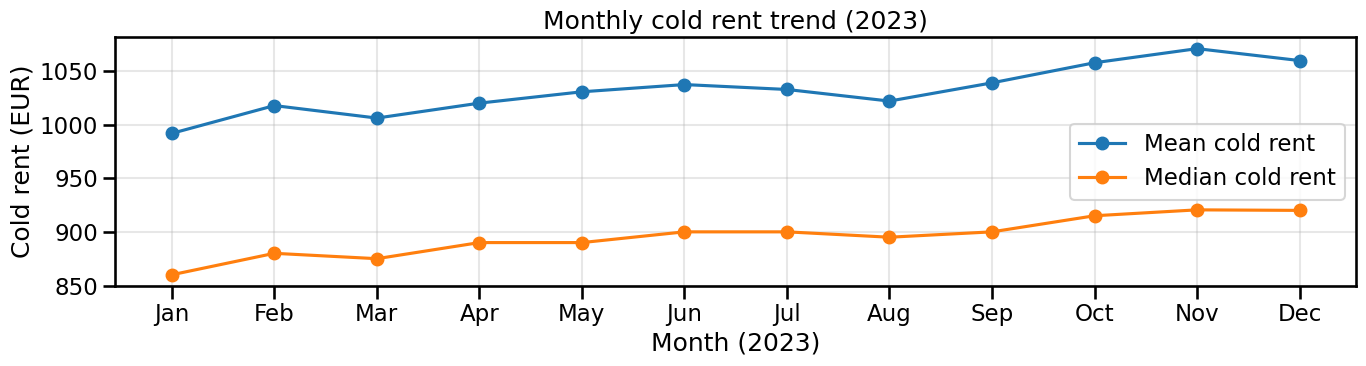

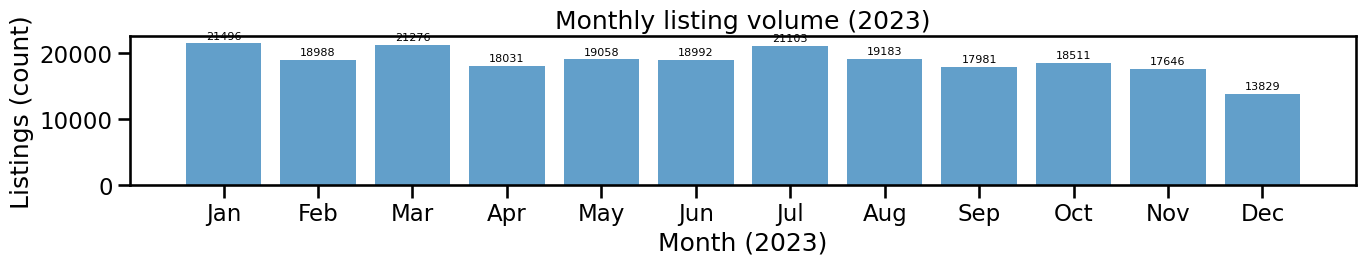

In [24]:
# Alternative (no dual axis): price trend and volume shown separately

# Price trend
plt.figure(figsize=(14, 4))
plt.plot(monthly["month"], monthly["mean_cold_rent"], marker='o', label='Mean cold rent')
plt.plot(monthly["month"], monthly["median_cold_rent"], marker='o', label='Median cold rent')
plt.xticks(monthly["month"], monthly["month_name"])
plt.xlabel('Month (2023)')
plt.ylabel('Cold rent (EUR)')
plt.title('Monthly cold rent trend (2023)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Listing volume
plt.figure(figsize=(14, 3))
bars = plt.bar(monthly["month"], monthly["count"], alpha=0.7)
plt.xticks(monthly["month"], monthly["month_name"])
plt.xlabel('Month (2023)')
plt.ylabel('Listings (count)')
plt.title('Monthly listing volume (2023)')
plt.bar_label(bars, padding=2, fontsize=8)
plt.tight_layout()
plt.show()


### 3.7.2 Market speed by segment: estate type
A practical question is whether **houses vs apartments** differ in how long listings stay online.
We look at `daysActive_clean` by `estateType` and (optionally) how this interacts with price.

**Important limitation:** `daysActive_clean` measures *observed* time online in the crawl. It may not equal true ‘time to rent’ because some listings can be **right-censored** (still active at the end of observation) or intermittently missing. Treat market-speed results as indicative, not causal.


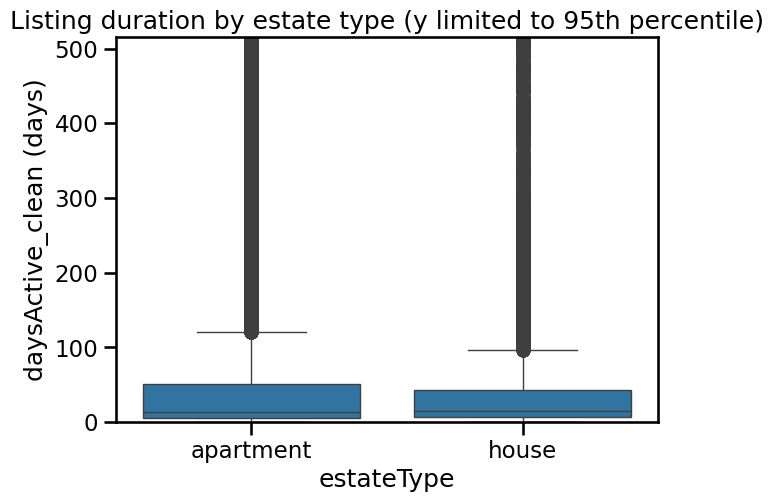

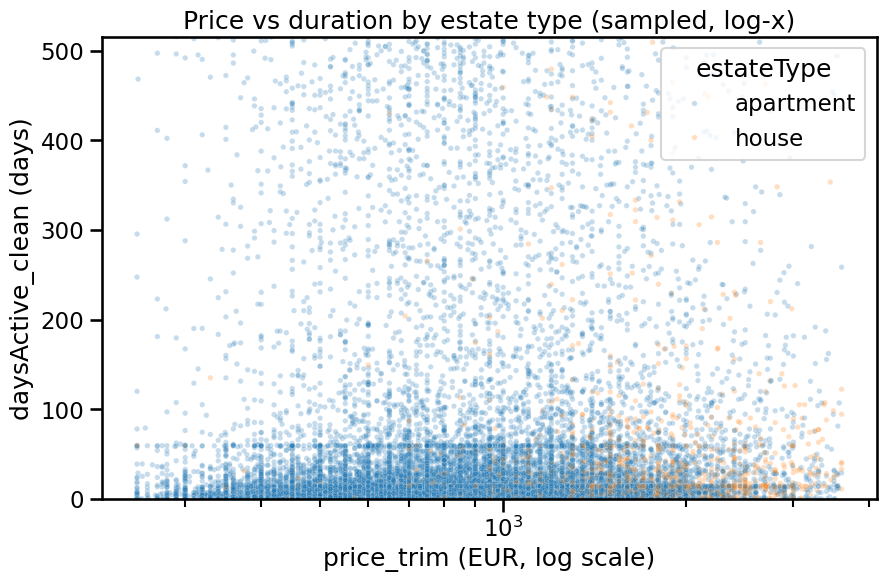

estateType
house        14.430156
apartment    14.045321
Name: daysActive_clean, dtype: float64

In [25]:
# Market speed by estateType (trim extreme durations for readability)
ms = df.dropna(subset=["estateType", "daysActive_clean", "price_trim"]).copy()
ms = ms[ms["price_trim"] > 0]

# Trim extreme durations for plotting (keep data for summaries)
ms_plot = ms[ms["daysActive_clean"] <= ms["daysActive_clean"].quantile(0.99)].copy()

plt.figure(figsize=(7, 5))
sns.boxplot(data=ms_plot, x="estateType", y="daysActive_clean")
plt.ylim(0, ms_plot["daysActive_clean"].quantile(0.95))
plt.title("Listing duration by estate type (y limited to 95th percentile)")
plt.ylabel("daysActive_clean (days)")
plt.xlabel("estateType")
plt.show()

# Scatter (sample for speed, log-x to spread out high prices)
sample = ms_plot.sample(20000, random_state=42) if len(ms_plot) > 20000 else ms_plot

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x="price_trim", y="daysActive_clean",
                hue="estateType", alpha=0.25, s=15)
plt.xscale("log")
plt.ylim(0, ms_plot["daysActive_clean"].quantile(0.95))
plt.title("Price vs duration by estate type (sampled, log-x)")
plt.xlabel("price_trim (EUR, log scale)")
plt.ylabel("daysActive_clean (days)")
plt.show()

display(ms.groupby("estateType")["daysActive_clean"].median().sort_values(ascending=False))


# 4) Asking and Answering Questions

In this section we formulate concrete, presentation-ready questions and answer them using the cleaned/trimmed variables.

We aim for:
- clear question → clear metric → clear visualization → careful interpretation
- Median is preferred over mean for skewed distributions with long tails.

## Q1 — How do rent levels differ across platforms?
We compared platforms beyond duration. Below we add a compact summary for **typical price levels** by platform.


,listings,median_days,median_rent_per_sqm,median_cold_rent
main_platform,,,,
immoscout,79432,13.992763,15.974627,1138.0
multiple,32264,113.320326,13.909091,958.0
immowelt,33138,13.353219,11.372549,820.0
ebay,91096,11.077035,10.666667,730.0


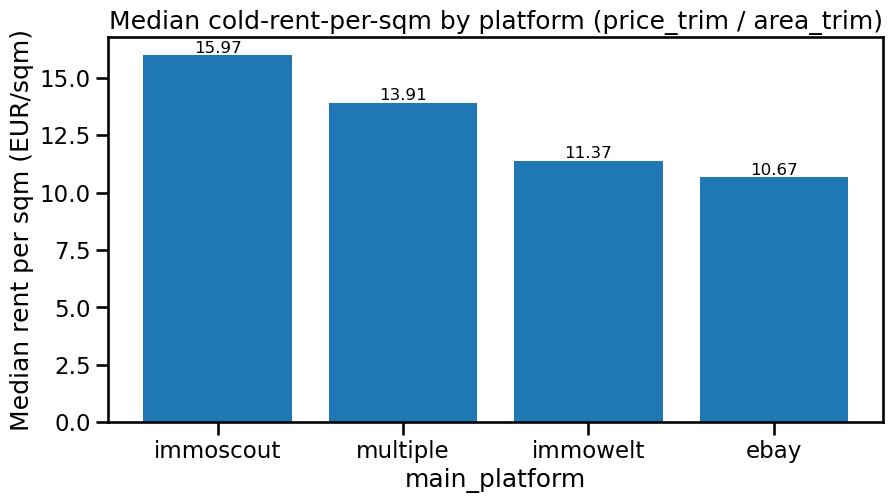

In [26]:
# Ensure rent_per_sqm exists (calculate if not present)
if "rent_per_sqm" not in df.columns:
    df["rent_per_sqm"] = df["price_trim"] / df["area_trim"]

platform_stats = (df.groupby("main_platform")
                     .agg(listings=("main_platform", "size"),
                          median_days=("daysActive_clean", "median"),
                          median_rent_per_sqm=("rent_per_sqm", "median"),
                          median_cold_rent=("price_trim", "median"))
                  )

display(platform_stats.sort_values("median_rent_per_sqm", ascending=False))

# A plot that is easy to present: median rent per sqm by platform
order = platform_stats.sort_values("median_rent_per_sqm", ascending=False).index
plt.figure(figsize=(10, 5))
bars = plt.bar(order, platform_stats.loc[order, "median_rent_per_sqm"])
plt.title("Median cold-rent-per-sqm by platform (price_trim / area_trim)")
plt.ylabel("Median rent per sqm (EUR/sqm)")
plt.xlabel("main_platform")
# Add value labels on bars
for bar, val in zip(bars, platform_stats.loc[order, "median_rent_per_sqm"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=12)
plt.show()


In [27]:
# Optional: platform exposure view (explode multi-platform listings)
# Note: a cross-posted listing appears once per platform in this view (not a unique-listing count).

_df_exp = df.explode("platforms_list").rename(columns={"platforms_list": "platform_exposure"})

if "rent_per_sqm" not in _df_exp.columns:
    _df_exp["rent_per_sqm"] = _df_exp["price_trim"] / _df_exp["area_trim"]

expo_stats = (_df_exp.groupby("platform_exposure")
               .agg(exposures=("platform_exposure", "size"),
                    median_days=("daysActive_clean", "median"),
                    median_rent_per_sqm=("rent_per_sqm", "median"),
                    median_cold_rent=("price_trim", "median"))
             ).sort_values("median_rent_per_sqm", ascending=False)

display(expo_stats)


,exposures,median_days,median_rent_per_sqm,median_cold_rent
platform_exposure,,,,
wggesucht,3587,573.296522,16.500000,640.000
immoscout,103449,14.346859,15.698925,1110.000
immobilie1,251,629.782521,13.239875,975.000
immowelt,55915,25.149437,12.159091,890.635
ebay,112950,15.332925,11.205985,763.000


In [28]:
# Single-platform-only: platform summary stats
_df_single = df[df["main_platform"] != "multiple"].copy()

if "rent_per_sqm" not in _df_single.columns:
    _df_single["rent_per_sqm"] = _df_single["price_trim"] / _df_single["area_trim"]

_platform_stats_single = (_df_single.groupby("main_platform")
                           .agg(listings=("main_platform", "size"),
                                median_days=("daysActive_clean", "median"),
                                median_rent_per_sqm=("rent_per_sqm", "median"),
                                median_cold_rent=("price_trim", "median"))
                         )

display(_platform_stats_single.sort_values("median_rent_per_sqm", ascending=False))


,listings,median_days,median_rent_per_sqm,median_cold_rent
main_platform,,,,
immoscout,79432,13.992763,15.974627,1138.0
immowelt,33138,13.353219,11.372549,820.0
ebay,91096,11.077035,10.666667,730.0


## Q2 — Are higher-priced listings active longer?

We work by:
- split price into quartiles (based on `price_trim`)
- compare duration distributions across quartiles

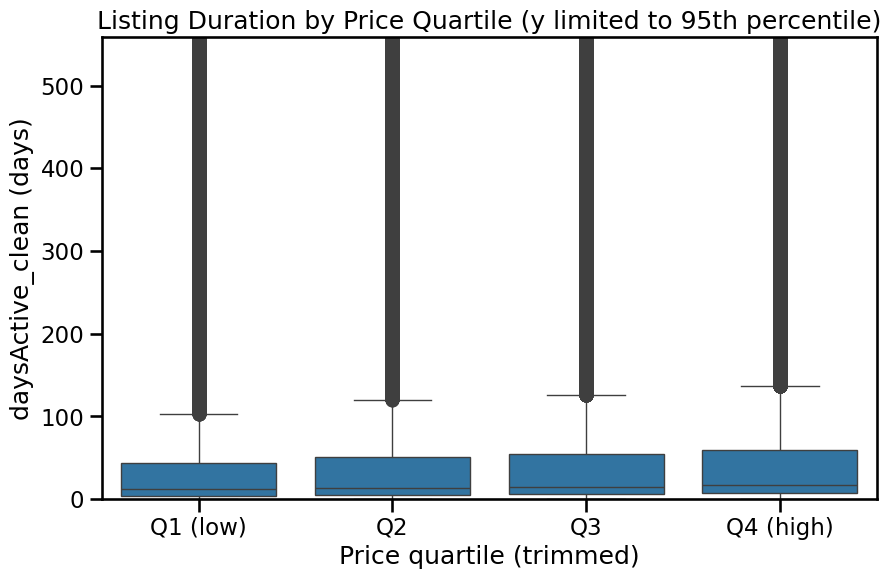

price_quartile
Q1 (low)     12.003247
Q2           13.990591
Q3           14.199668
Q4 (high)    16.529976
Name: daysActive_clean, dtype: float64

In [29]:
sub_q2 = df[["daysActive_clean", "price_trim"]].dropna().copy()
sub_q2["price_quartile"] = pd.qcut(sub_q2["price_trim"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=sub_q2, x="price_quartile", y="daysActive_clean")
plt.ylim(0, sub_q2["daysActive_clean"].quantile(0.95))
plt.title("Listing Duration by Price Quartile (y limited to 95th percentile)")
plt.xlabel("Price quartile (trimmed)")
plt.ylabel("daysActive_clean (days)")
plt.show()

display(sub_q2.groupby("price_quartile", observed=True)["daysActive_clean"].median())

## Q3 — How strongly is rent explained by area?

We use:
- correlation (Spearman)
- a more interpretable metric: **rent per sqm** by area group

This can reveal **non-linear patterns** (e.g., small apartments being more expensive per sqm).

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\1868945821.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = (sub_q3.groupby("area_group")["rent_per_sqm"]


,count,median
area_group,,
<=30,12138,20.400000
30-50,36683,15.000000
50-70,56419,13.230769
70-90,49049,12.267394
90-120,34403,11.660889
120-200,20321,11.038961
200+,36,9.852217


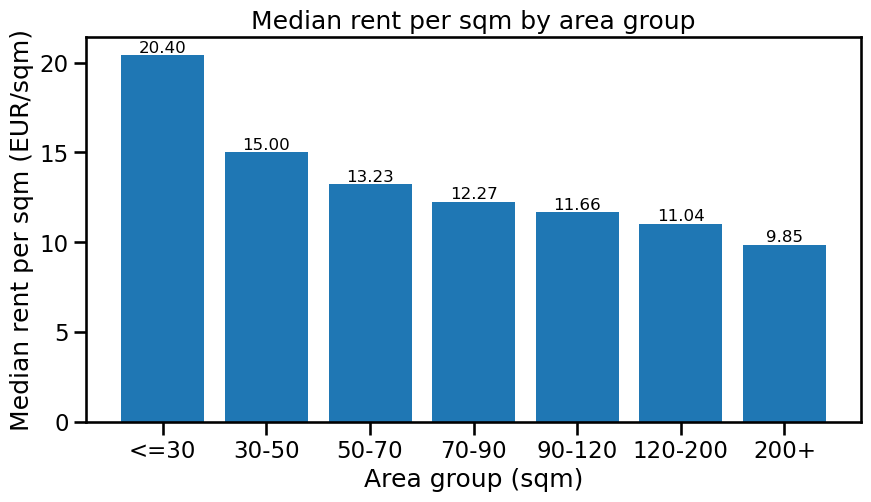

In [30]:
sub_q3 = df[["area_trim", "rent_per_sqm"]].dropna().copy()

# Area groups
sub_q3["area_group"] = pd.cut(sub_q3["area_trim"], bins=[0, 30, 50, 70, 90, 120, 200, np.inf],
                              labels=["<=30", "30-50", "50-70", "70-90", "90-120", "120-200", "200+"])

group_stats = (sub_q3.groupby("area_group")["rent_per_sqm"]
                 .agg(count="count", median="median")
                 .dropna())

display(group_stats)

plt.figure(figsize=(10, 5))
bars = plt.bar(group_stats.index.astype(str), group_stats["median"])
plt.title("Median rent per sqm by area group")
plt.xlabel("Area group (sqm)")
plt.ylabel("Median rent per sqm (EUR/sqm)")
# Add value labels on bars
for b, val in zip(bars, group_stats["median"]):
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=12)
plt.show()

## Q4 — Which premium features are associated with higher **cold rent**?

We compare **rent per sqm** (based on cold rent) across selected binary features.

Correlation heatmaps are compact but can be hard to interpret in € terms. A more intuitive approach is to compute the **median difference** in `rent_per_sqm` between listings **with vs without** a feature.

We treat this as descriptive, not causal: features correlate with location/quality and other unobserved factors.


,feature,median_without,median_with,premium_eur_per_sqm,premium_pct,n_without,n_with
3,lift,14.500000,16.879759,2.379759,16.412131,60212,53296
0,balcony,11.940299,13.970588,2.030290,17.003676,87424,116896
5,furnished,13.933730,15.272074,1.338344,9.605067,1019,40961
4,newlyConstructed,12.903226,13.899973,0.996747,7.724788,178042,31007
2,cellarOrAttic,13.810079,13.656999,-0.153080,-1.108466,40270,126828
1,barrierFree,15.383380,14.716477,-0.666903,-4.335219,86518,26480


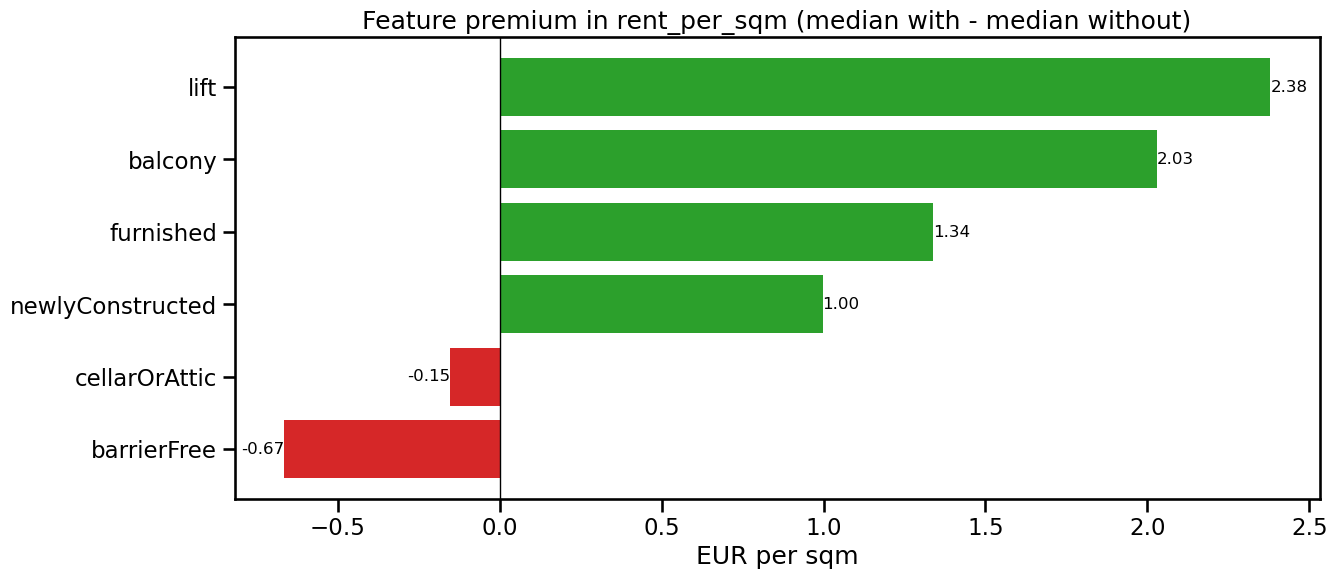

In [31]:
# Ensure rent_per_sqm exists (calculate if not present)
if "rent_per_sqm" not in df.columns:
    df["rent_per_sqm"] = df["price_trim"] / df["area_trim"]

# Ensure _num columns exist (create if not present)
bool_cols = ["balcony", "barrierFree", "cellarOrAttic", "lift", "newlyConstructed", "furnished"]
for c in bool_cols:
    col_name = c + "_num"
    if col_name not in df.columns and c in df.columns:
        df[col_name] = df[c].map({True: 1, False: 0})

# Feature premiums: median rent_per_sqm difference between feature=1 and feature=0
premium_features = ["balcony_num", "barrierFree_num", "cellarOrAttic_num", "lift_num", "newlyConstructed_num", "furnished_num"]

rows = []
for f in premium_features:
    tmp = df[[f, "rent_per_sqm"]].dropna().copy()
    if tmp[f].nunique() < 2:
        continue
    med = tmp.groupby(f)["rent_per_sqm"].median()
    cnt = tmp.groupby(f)["rent_per_sqm"].size()
    prem = med.get(1, np.nan) - med.get(0, np.nan)
    base = med.get(0, np.nan)
    prem_pct = (prem / base) * 100 if (base != 0 and not pd.isna(base)) else np.nan

    rows.append({
        "feature": f.replace("_num", ""),
        "median_without": med.get(0, np.nan),
        "median_with": med.get(1, np.nan),
        "premium_eur_per_sqm": prem,
        "premium_pct": prem_pct,
        "n_without": int(cnt.get(0, 0)),
        "n_with": int(cnt.get(1, 0)),
    })

premium_df = pd.DataFrame(rows).sort_values("premium_eur_per_sqm", ascending=False)
display(premium_df)

plt.figure(figsize=(14, 6))
# Different colors for positive (green) and negative (red) values
colors = ['tab:green' if x >= 0 else 'tab:red' for x in premium_df["premium_eur_per_sqm"]]
bars = plt.barh(premium_df["feature"], premium_df["premium_eur_per_sqm"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Feature premium in rent_per_sqm (median with - median without)")
plt.xlabel("EUR per sqm")
plt.gca().invert_yaxis()
# Add value labels on bars
for b, val in zip(bars, premium_df["premium_eur_per_sqm"]):
    width = b.get_width()
    plt.text(width, b.get_y() + b.get_height()/2.,
            f'{val:.2f}',
            ha='left' if width >= 0 else 'right', va='center', fontsize=12)
plt.show()


### Bonus for Q4: floor effect
Floor numbers can be noisy (different conventions; missing values). Still, it can be insightful to compare price levels across floor bands.


Total records: 173142
Records with floor_trim = -1: 0
Records with floor_trim between -1.5 and -0.5: 0


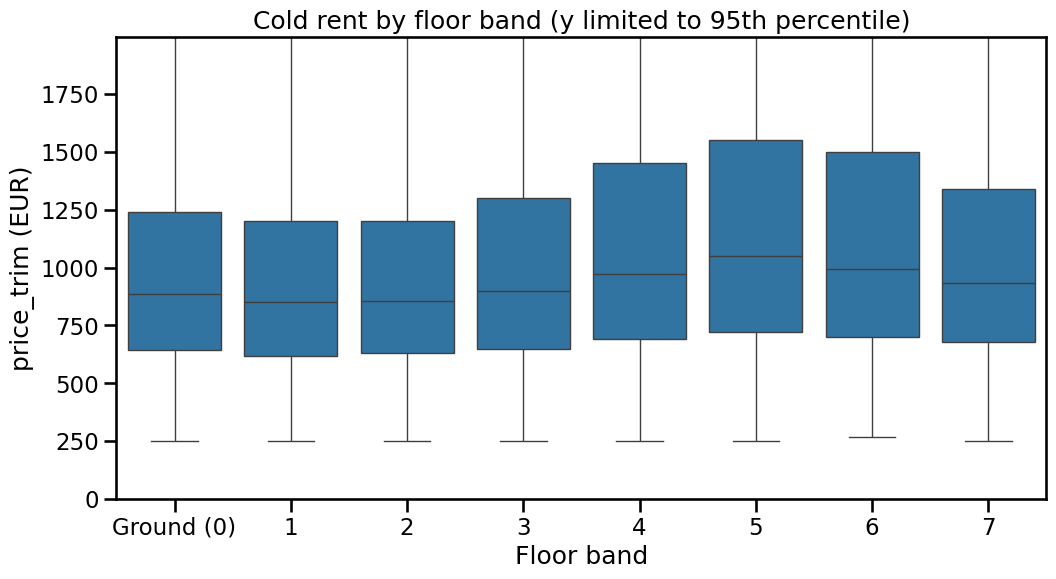

floor_bin
Ground (0)     885.0
1              850.0
2              855.0
3              900.0
4              973.0
5             1050.0
6              995.0
7              935.0
Name: price_trim, dtype: float64

In [32]:
# Floor effect: compare cold rent across floor bins (readable categories)
floor_df = df.dropna(subset=["floor_trim", "price_trim"]).copy()

# Keep a reasonable range for presentation
floor_df = floor_df[(floor_df["floor_trim"] >= -1) & (floor_df["floor_trim"] <= 10)]

# Diagnostic: Check if there's any data with floor = -1
print(f"Total records: {len(floor_df)}")
print(f"Records with floor_trim = -1: {(floor_df['floor_trim'] == -1).sum()}")
print(f"Records with floor_trim between -1.5 and -0.5: {((floor_df['floor_trim'] > -1.5) & (floor_df['floor_trim'] <= -0.5)).sum()}")

# Fix: Adjust bin boundaries to better capture floor=-1 and use include_lowest=True
# Also: Ensure labels match the number of intervals (11 bin edges = 10 intervals, need 10 labels)
bins = [ -0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
labels = [ "Ground (0)", "1", "2", "3", "4", "5", "6", "7"]

floor_df["floor_bin"] = pd.cut(floor_df["floor_trim"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=floor_df, x="floor_bin", y="price_trim")
plt.ylim(0, floor_df["price_trim"].quantile(0.95))
plt.title("Cold rent by floor band (y limited to 95th percentile)")
plt.xlabel("Floor band")
plt.ylabel("price_trim (EUR)")
plt.show()

display(floor_df.groupby("floor_bin", observed=True)["price_trim"].median())


### Bonus for Q4: furnished vs unfurnished by top 10 cities
To make the "furnished premium" more concrete, we compare **median rent_per_sqm** between furnished and unfurnished listings in the most frequent cities.


furnished_num,Unfurnished,Furnished
city,,
München,24.884615,27.692308
Regensburg,15.500000,15.948143
Augsburg,14.194444,17.142857
Ingolstadt,15.366510,15.780435
Erlangen,13.041667,16.708023
Würzburg,13.820000,15.428571
Nürnberg,12.400000,15.264955
Fürth,12.296296,14.698068
Bayreuth,12.979912,13.725490


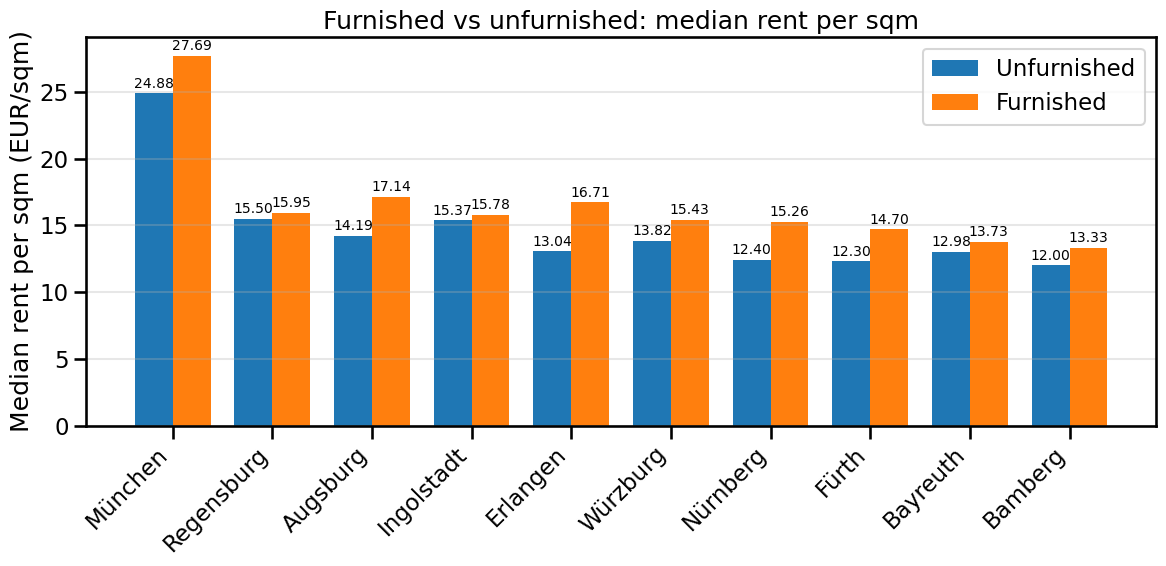

In [33]:
top_cities = df["city"].value_counts().head(10).index
furn_df = df[df["city"].isin(top_cities)].dropna(subset=["rent_per_sqm", "furnished_num"]).copy()

# City x furnishing summary
city_furn = (furn_df.groupby(["city", "furnished_num"])["rent_per_sqm"]
                    .median()
                    .unstack()
                    .rename(columns={0: "Unfurnished", 1: "Furnished"}))

# Keep cities sorted by overall level
city_furn["avg"] = city_furn.mean(axis=1)
city_furn = city_furn.sort_values("avg", ascending=False).drop(columns=["avg"])

display(city_furn)

# Matplotlib grouped bars (simple + explicit)
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(city_furn.index))
width = 0.38

vals_unf = city_furn.get("Unfurnished")
vals_fur = city_furn.get("Furnished")

bars1 = ax.bar([i - width/2 for i in x], vals_unf, width, label='Unfurnished')
bars2 = ax.bar([i + width/2 for i in x], vals_fur, width, label='Furnished')

ax.set_xticks(list(x))
ax.set_xticklabels(city_furn.index, rotation=45, ha='right')
ax.set_ylabel('Median rent per sqm (EUR/sqm)')
ax.set_title('Furnished vs unfurnished: median rent per sqm')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=10)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=10)

plt.tight_layout()
plt.show()


## Q5 — Does offerer type (private vs non-private) relate to pricing or duration?

Because `offerer` is a dictionary, we extracted `privateOffer`.
We compare:
- `daysActive_clean` and `rent_per_sqm` by `privateOffer`

Missing values for `privateOffer` are kept as `NaN` and excluded from this comparison only.

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\2484109926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_q5, x="privateOffer", y="daysActive_clean", palette=["#FF6B6B", "#4ECDC4"])


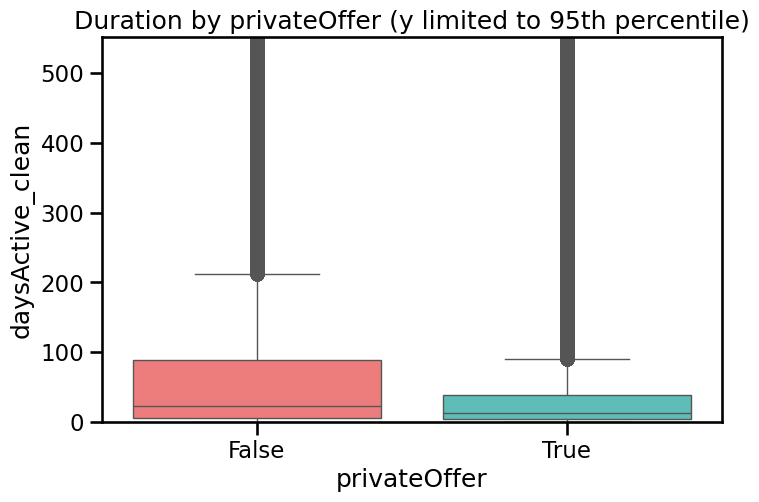

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_24436\2484109926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_q5, x="privateOffer", y="rent_per_sqm", palette=["#FF6B6B", "#4ECDC4"])


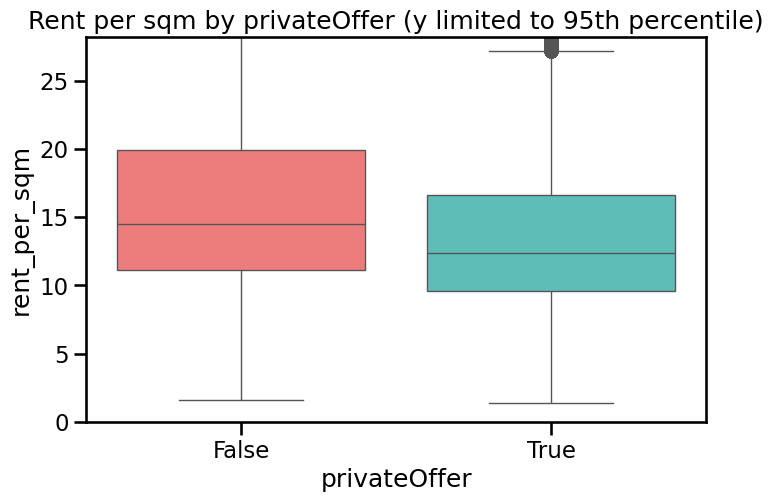

,daysActive_clean,rent_per_sqm
privateOffer,,
False,23.017540,14.535544
True,13.320051,12.380952


In [34]:
sub_q5 = df[["privateOffer", "daysActive_clean", "rent_per_sqm"]].dropna(subset=["privateOffer"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=sub_q5, x="privateOffer", y="daysActive_clean", palette=["#FF6B6B", "#4ECDC4"])
plt.ylim(0, sub_q5["daysActive_clean"].quantile(0.95))
plt.title("Duration by privateOffer (y limited to 95th percentile)")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=sub_q5, x="privateOffer", y="rent_per_sqm", palette=["#FF6B6B", "#4ECDC4"])
plt.ylim(0, sub_q5["rent_per_sqm"].quantile(0.95))
plt.title("Rent per sqm by privateOffer (y limited to 95th percentile)")
plt.show()

display(sub_q5.groupby("privateOffer")[["daysActive_clean", "rent_per_sqm"]].median())

## Wrap-up: what we learned

**Data quality & cleaning**
- Near-duplicates exist (cross-posting / re-posting), even if `_id` is unique.
- Missingness is often **platform-specific** → not missing at random.
- `daysActive` shows occasional inconsistencies → recomputing from timestamps is safer.
- `price` and `area` contain extreme outliers → trimming is necessary for interpretable EDA.

**Key findings to highlight in a presentation**
- Listing duration differs by platform (compare medians + boxplots).
- `area` typically correlates with `price`, but the relationship is noisy and skewed.
- Feature correlations are generally modest; interpretation needs caution.
- Rent per sqm varies regionally (counties) and by platform.